# RoadSafe — Road Accident Severity Prediction and Explainable Risk Analysis

## Exploratory Data Analysis (EDA)

This notebook performs exploratory data analysis on the road accident dataset used for the RoadSafe project.

### Objectives of EDA
- Understand the structure and characteristics of the dataset.
- Identify missing and duplicate values.
- Analyze the distribution of accident severity.
- Study numerical and categorical features.
- Identify important patterns and relationships in the data.
- Prepare the dataset for subsequent preprocessing and machine learning.

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
print("RoadSafe environment is ready!")
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)
print("Scikit-learn version:", sklearn.__version__)

RoadSafe environment is ready!
Pandas version: 3.0.5
NumPy version: 2.5.2
Scikit-learn version: 1.9.0


## 1. Dataset Loading

The selected road accident dataset is loaded into a Pandas DataFrame for exploratory data analysis and subsequent machine learning tasks.

In [76]:
df = pd.read_csv("../data/Road.csv")
print("Dataset loaded successfully!")

Dataset loaded successfully!


## 2. Initial Dataset Preview

The first five records of the dataset are displayed to obtain an initial understanding of the available accident-related attributes.

In [77]:
df.head()

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,...,Going straight,Driver or rider,Male,31-50,3,Driver,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury
3,1:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,...,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,1:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury


## 3. Dataset Dimensions

The dimensions of the dataset are examined to determine the number of accident records and features available for analysis.

In [78]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 12316
Number of columns: 32


## 4. Dataset Information

The structure of the dataset is examined to identify feature data types and determine the presence of missing values.

In [79]:

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12316 entries, 0 to 12315
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   Time                         12316 non-null  str  
 1   Day_of_week                  12316 non-null  str  
 2   Age_band_of_driver           12316 non-null  str  
 3   Sex_of_driver                12316 non-null  str  
 4   Educational_level            11575 non-null  str  
 5   Vehicle_driver_relation      11737 non-null  str  
 6   Driving_experience           11487 non-null  str  
 7   Type_of_vehicle              11366 non-null  str  
 8   Owner_of_vehicle             11834 non-null  str  
 9   Service_year_of_vehicle      8388 non-null   str  
 10  Defect_of_vehicle            7889 non-null   str  
 11  Area_accident_occured        12077 non-null  str  
 12  Lanes_or_Medians             11931 non-null  str  
 13  Road_allignment              12174 non-null  str  
 14  T

## 5. Feature and Target Variables

The names of all variables in the dataset are displayed to understand the available input features and identify the target variable.

In [80]:

print("Columns in the dataset:\n")
for column in df.columns:
    print(column)

Columns in the dataset:

Time
Day_of_week
Age_band_of_driver
Sex_of_driver
Educational_level
Vehicle_driver_relation
Driving_experience
Type_of_vehicle
Owner_of_vehicle
Service_year_of_vehicle
Defect_of_vehicle
Area_accident_occured
Lanes_or_Medians
Road_allignment
Types_of_Junction
Road_surface_type
Road_surface_conditions
Light_conditions
Weather_conditions
Type_of_collision
Number_of_vehicles_involved
Number_of_casualties
Vehicle_movement
Casualty_class
Sex_of_casualty
Age_band_of_casualty
Casualty_severity
Work_of_casuality
Fitness_of_casuality
Pedestrian_movement
Cause_of_accident
Accident_severity


## 6. Accident Severity Distribution

The target variable, `Accident_severity`, represents the severity category of each recorded accident. Its distribution is analyzed to understand the number of observations in each class.

In [81]:

severity_counts = df["Accident_severity"].value_counts()
print("Accident Severity Distribution:\n")
print(severity_counts)

Accident Severity Distribution:

Accident_severity
Slight Injury     10415
Serious Injury     1743
Fatal injury        158
Name: count, dtype: int64


## 7. Missing Value Analysis

Missing values are examined to determine the completeness of the dataset. Identifying incomplete features is important because missing values may affect model training and will need to be handled during the preprocessing stage.

In [82]:
missing_count = df.isnull().sum()
missing_percentage = (missing_count / len(df)) * 100
missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percentage
})
missing_summary = missing_summary.sort_values(
    by="Missing Count",
    ascending=False
)
missing_summary

,Missing Count,Missing Percentage
Defect_of_vehicle,4427,35.945112
Service_year_of_vehicle,3928,31.893472
Work_of_casuality,3198,25.966223
Fitness_of_casuality,2635,21.394933
Type_of_vehicle,950,7.713543
Types_of_Junction,887,7.202014
Driving_experience,829,6.731082
Educational_level,741,6.016564
Vehicle_driver_relation,579,4.701202
Owner_of_vehicle,482,3.913608


In [83]:
missing_summary[missing_summary["Missing Count"] > 0]

,Missing Count,Missing Percentage
Defect_of_vehicle,4427,35.945112
Service_year_of_vehicle,3928,31.893472
Work_of_casuality,3198,25.966223
Fitness_of_casuality,2635,21.394933
Type_of_vehicle,950,7.713543
Types_of_Junction,887,7.202014
Driving_experience,829,6.731082
Educational_level,741,6.016564
Vehicle_driver_relation,579,4.701202
Owner_of_vehicle,482,3.913608


## 8. Missing Value Visualization

The distribution of missing values across features is visualized to identify variables requiring greater attention during preprocessing.

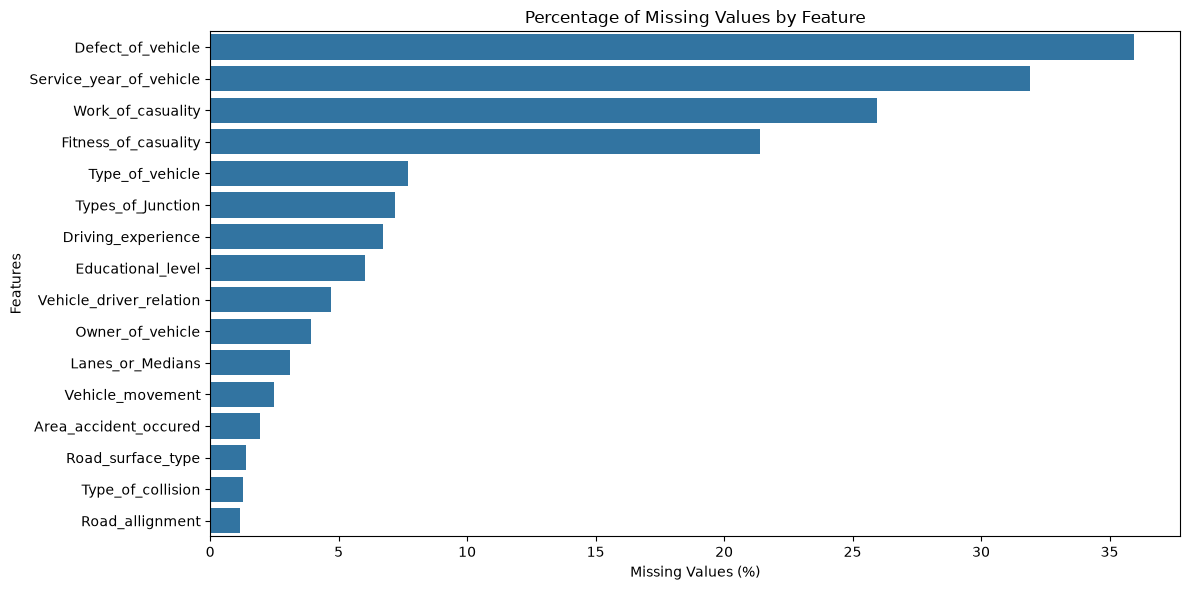

In [84]:
missing_features = missing_summary[
    missing_summary["Missing Count"] > 0
]
plt.figure(figsize=(12, 6))
sns.barplot(
    x=missing_features["Missing Percentage"],
    y=missing_features.index
)
plt.xlabel("Missing Values (%)")
plt.ylabel("Features")
plt.title("Percentage of Missing Values by Feature")
plt.tight_layout()
plt.show()

## 9. Duplicate Record Analysis

Duplicate records are identified to determine whether repeated accident observations are present in the dataset. Duplicate records can introduce bias during model training and may therefore require removal during preprocessing.

In [85]:
duplicate_count = df.duplicated().sum()
print("Number of duplicate records:", duplicate_count)

Number of duplicate records: 0


In [ ]:
duplicate_percentage = (duplicate_count / len(df)) * 100
print("Percentage of duplicate records:", round(duplicate_percentage, 2), "%")

Percentage of duplicate records: 0.0 %


## 10. Accident Severity Visualization

The distribution of accident severity classes is visualized to identify class imbalance and understand the relative frequency of each severity category.

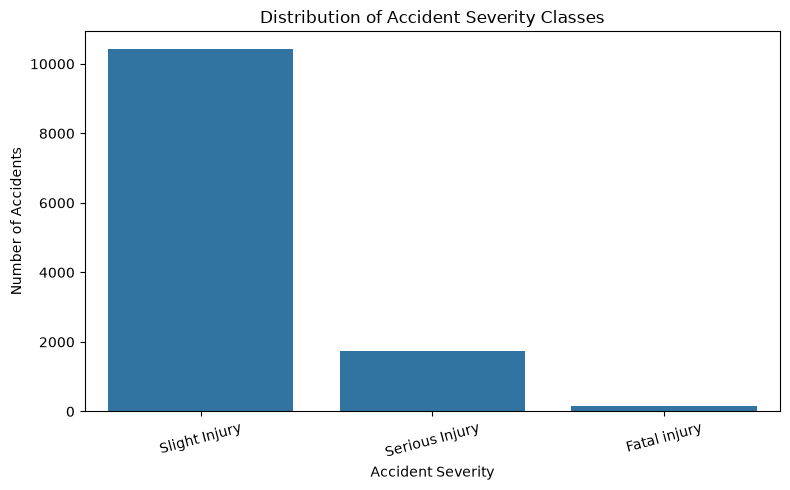

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df,
    x="Accident_severity"
)
plt.xlabel("Accident Severity")
plt.ylabel("Number of Accidents")
plt.title("Distribution of Accident Severity Classes")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 11. Accident Severity Class Percentages

The percentage distribution of each accident severity class is calculated to quantify the degree of class imbalance in the target variable.

In [ ]:
severity_percentage = (
    df["Accident_severity"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)
print("Accident Severity Percentage Distribution:\n")
print(severity_percentage)

Accident Severity Percentage Distribution:

Accident_severity
Slight Injury     84.56
Serious Injury    14.15
Fatal injury       1.28
Name: proportion, dtype: float64


## 12. Hidden Missing and Not-Applicable Values

In addition to standard null values detected by Pandas, the dataset contains categorical values such as `na` that may represent missing or not-applicable information.

These values are analyzed separately because replacing all `na` values blindly could distort the meaning of certain accident-related features. This distinction will be considered during the preprocessing stage.

In [ ]:

placeholder_values = ["na", "NaN", "nan", "unknown", "?", "-", ""]
placeholder_summary = {}
for column in df.columns:
    count = df[column].astype(str).str.strip().isin(placeholder_values).sum()    
    if count > 0:
        placeholder_summary[column] = count
placeholder_summary = pd.Series(
    placeholder_summary
).sort_values(ascending=False)
print("Potential placeholder / NA-like values:\n")
print(placeholder_summary)

Potential placeholder / NA-like values:

Casualty_class          4443
Age_band_of_casualty    4443
Sex_of_casualty         4443
Casualty_severity       4443
Driving_experience        33
dtype: int64


## 13. Categorical Feature Analysis

The number of unique categories in each feature is examined to understand the diversity of categorical variables and identify features that may require encoding during preprocessing.

In [ ]:
unique_counts = df.nunique().sort_values(ascending=False)
print("Number of unique values in each feature:\n")
print(unique_counts)

Number of unique values in each feature:

Time                           1074
Cause_of_accident                20
Type_of_vehicle                  17
Area_accident_occured            14
Vehicle_movement                 13
Type_of_collision                10
Weather_conditions                9
Road_allignment                   9
Pedestrian_movement               9
Types_of_Junction                 8
Number_of_casualties              8
Work_of_casuality                 7
Lanes_or_Medians                  7
Driving_experience                7
Educational_level                 7
Day_of_week                       7
Age_band_of_casualty              6
Number_of_vehicles_involved       6
Service_year_of_vehicle           6
Fitness_of_casuality              5
Road_surface_type                 5
Age_band_of_driver                5
Vehicle_driver_relation           4
Owner_of_vehicle                  4
Casualty_class                    4
Casualty_severity                 4
Light_conditions      

## 14. Numerical Feature Analysis

The numerical features are statistically analyzed to understand their central tendency, spread, and range before preprocessing.

In [ ]:
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns
df[numerical_columns].describe()

,Number_of_vehicles_involved,Number_of_casualties
count,12316.000000,12316.000000
mean,2.040679,1.548149
std,0.688790,1.007179
min,1.000000,1.000000
25%,2.000000,1.000000
50%,2.000000,1.000000
75%,2.000000,2.000000
max,7.000000,8.000000


## 15. Numerical Feature Distribution

The distributions of numerical accident-related features are visualized to identify their ranges, concentration, and potential outliers.

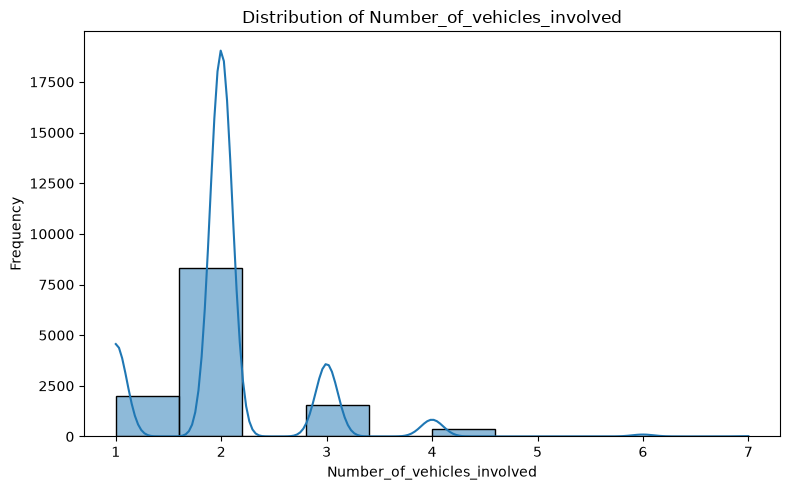

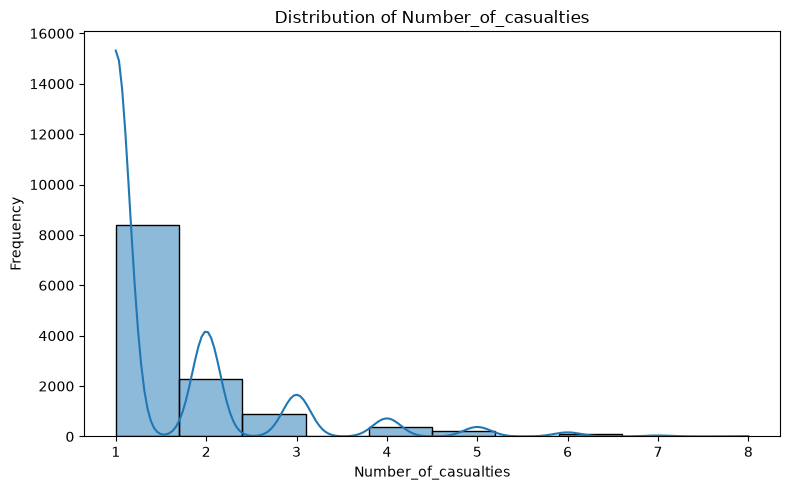

In [ ]:
for column in numerical_columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(
        data=df,
        x=column,
        bins=10,
        kde=True
    )
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

## 16. Numerical Features and Accident Severity

The relationship between numerical accident characteristics and severity is examined to determine whether the number of vehicles involved and the number of casualties vary across accident severity classes.

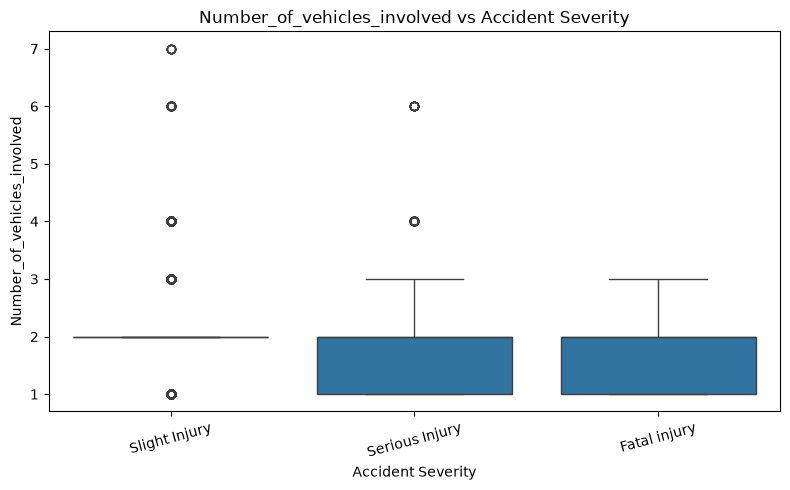

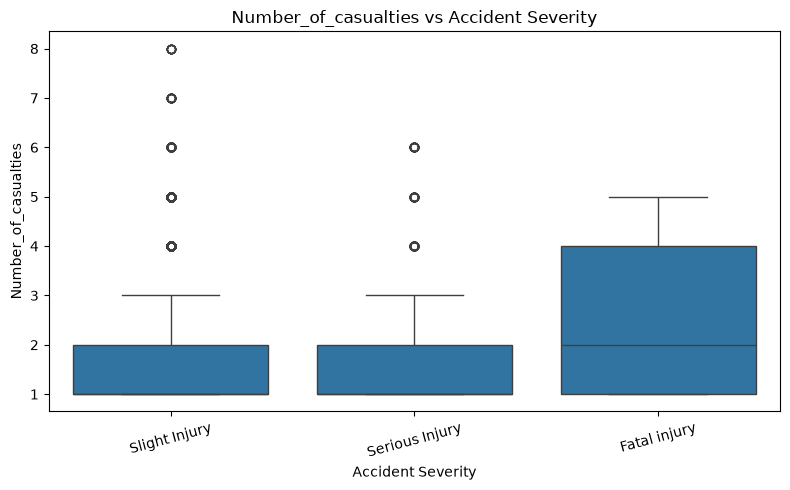

In [ ]:
for column in numerical_columns:
    plt.figure(figsize=(8, 5))
    sns.boxplot(
        data=df,
        x="Accident_severity",
        y=column
    )
    plt.title(f"{column} vs Accident Severity")
    plt.xlabel("Accident Severity")
    plt.ylabel(column)
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()

## 17. Categorical Features and Accident Severity

Key environmental, road, and accident-related categorical features are compared against accident severity to identify patterns and factors potentially associated with severe accidents.

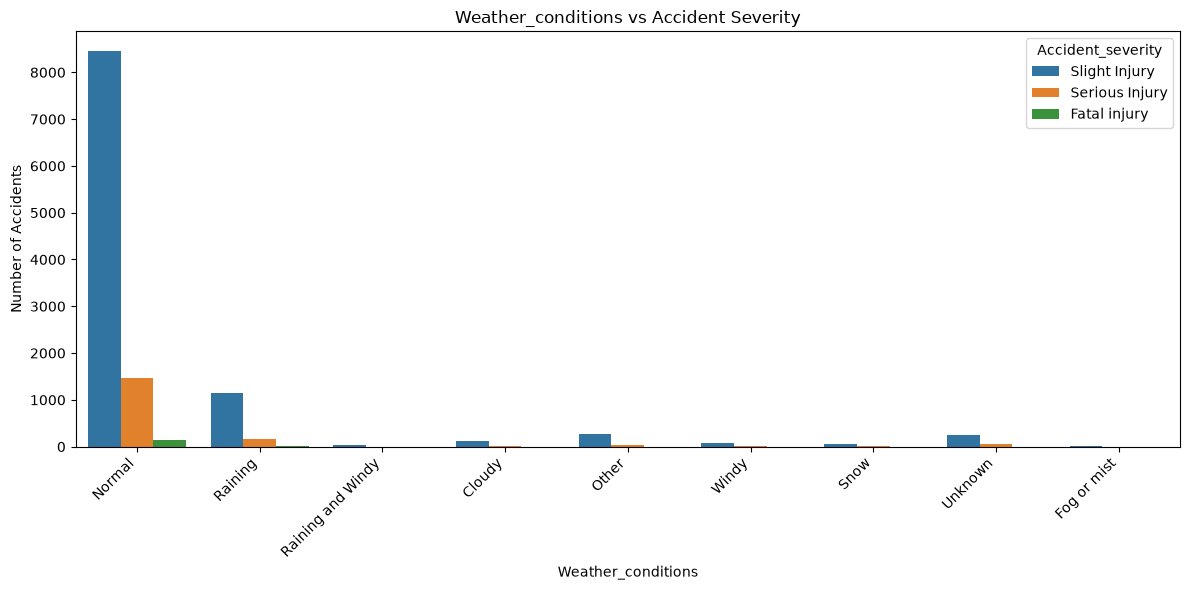

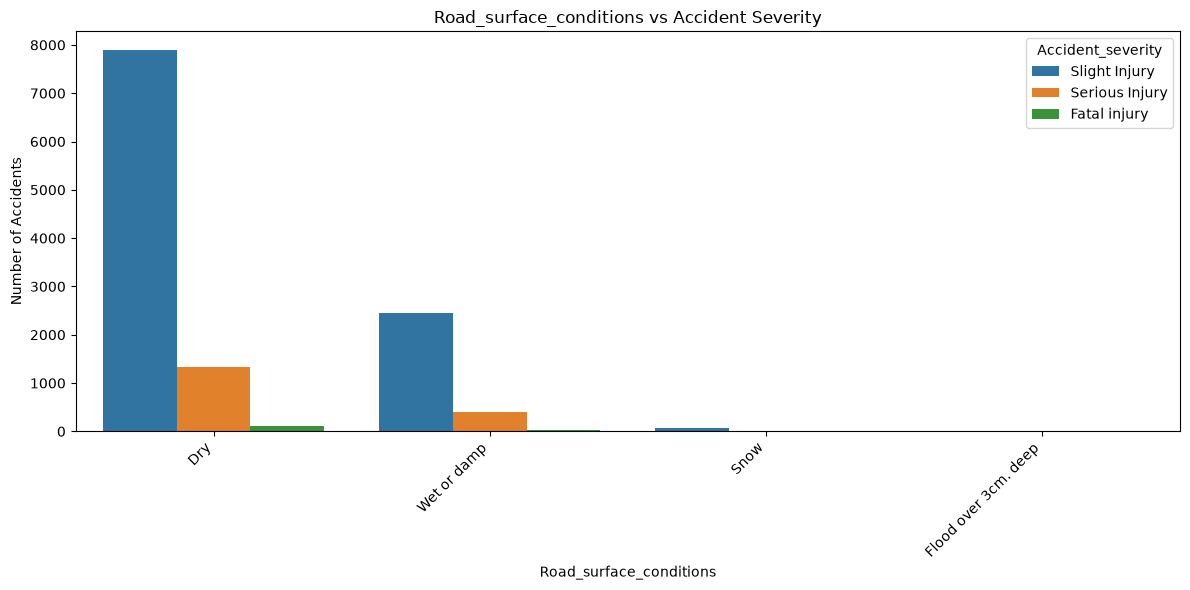

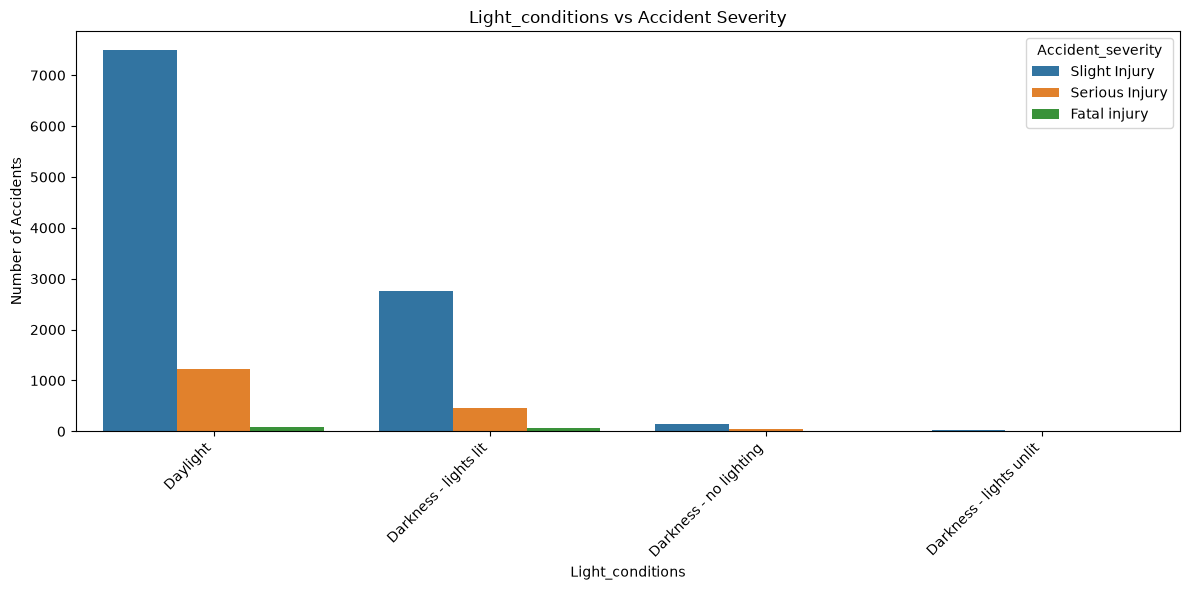

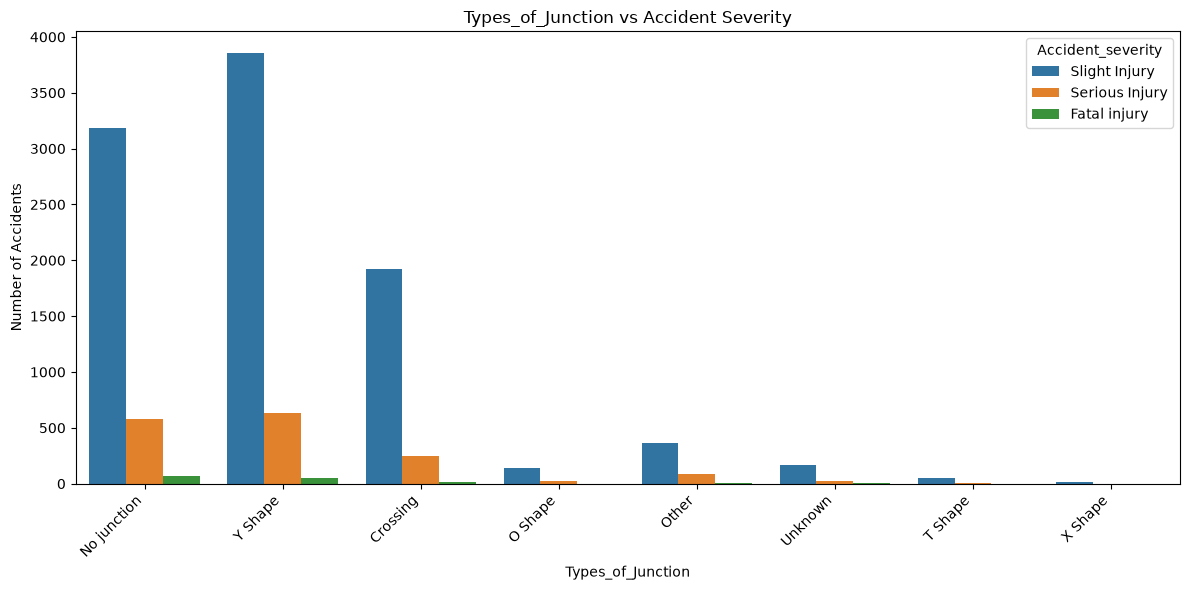

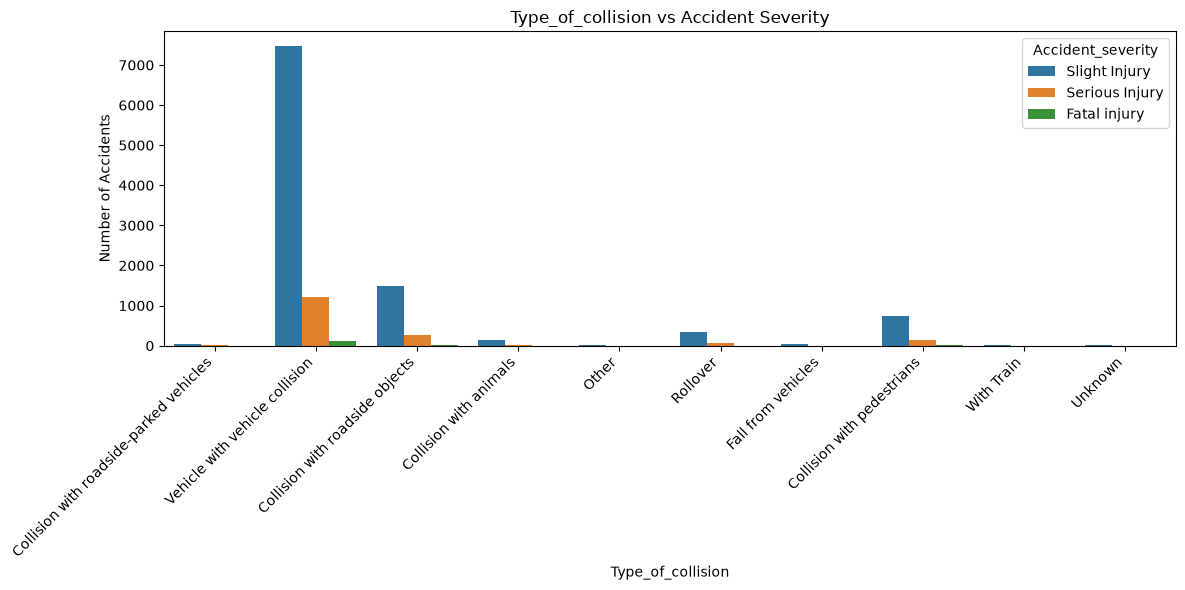

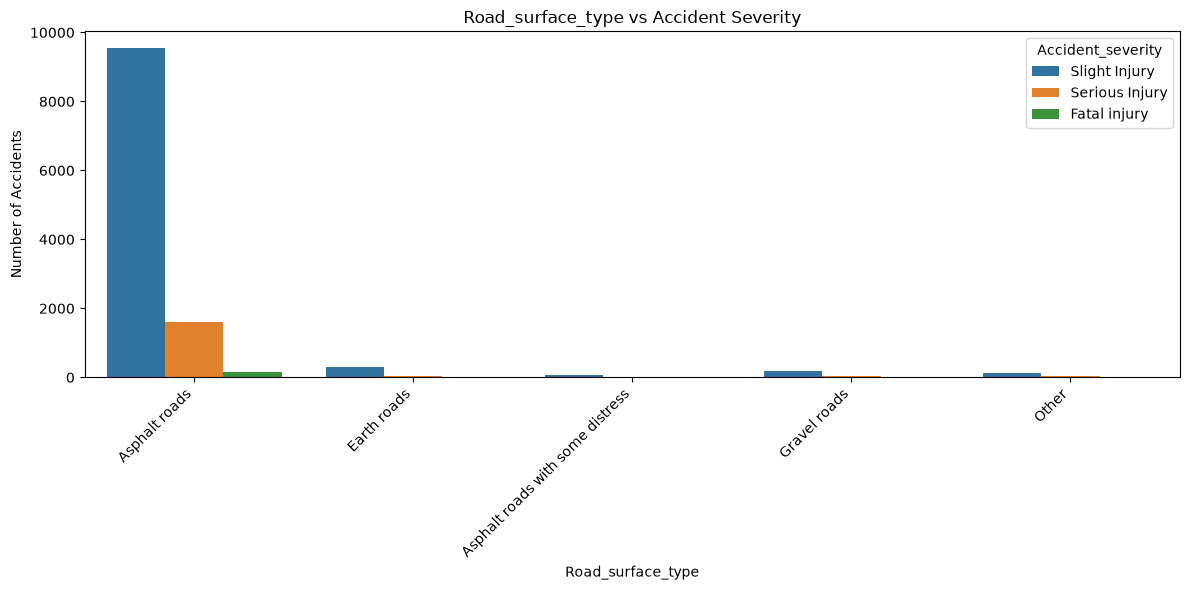

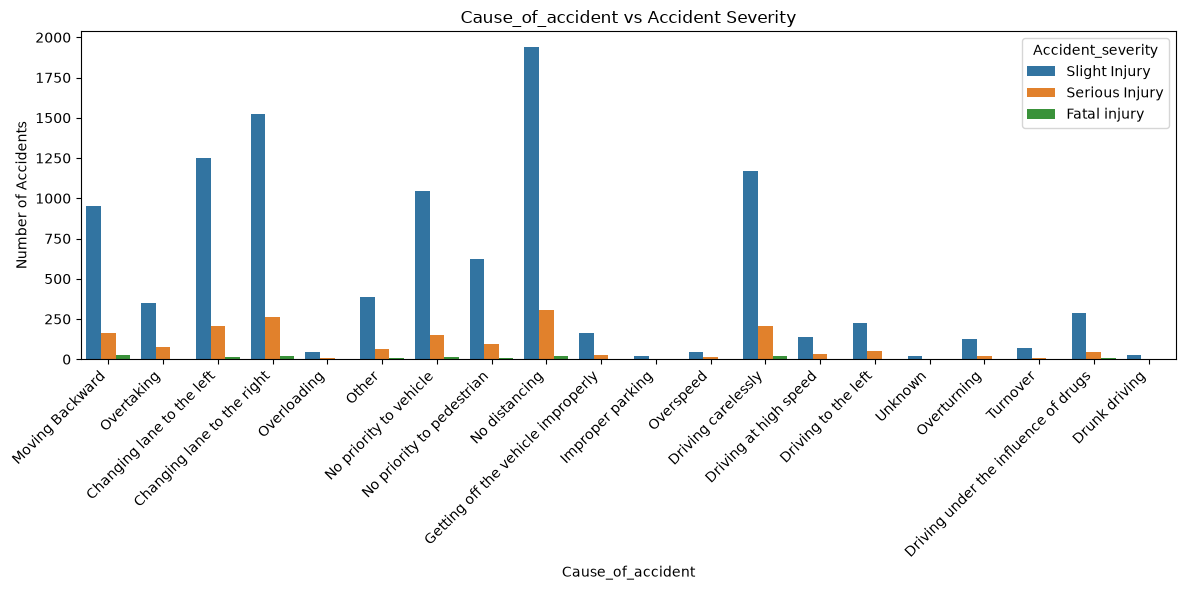

In [ ]:
important_categorical_features = [
    "Weather_conditions",
    "Road_surface_conditions",
    "Light_conditions",
    "Types_of_Junction",
    "Type_of_collision",
    "Road_surface_type",
    "Cause_of_accident"
]
for column in important_categorical_features:
    plt.figure(figsize=(12, 6))
    
    sns.countplot(
        data=df,
        x=column,
        hue="Accident_severity"
    )
    plt.title(f"{column} vs Accident Severity")
    plt.xlabel(column)
    plt.ylabel("Number of Accidents")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

## 18. Accident Time Analysis

The accident time variable is analyzed to identify temporal patterns in accident occurrence. The time information may later be transformed into meaningful temporal features during preprocessing.

In [ ]:
df["Accident_hour"] = pd.to_datetime(
    df["Time"],
    format="%H:%M:%S",
    errors="coerce"
).dt.hour
print("Accident hour distribution:")
print(df["Accident_hour"].value_counts().sort_index())

Accident hour distribution:
Accident_hour
0      206
1      134
2       84
3       84
4       91
5       76
6      214
7      532
8      828
9      559
10     500
11     603
12     691
13     772
14     639
15     874
16     921
17    1228
18     956
19     708
20     604
21     401
22     402
23     209
Name: count, dtype: int64


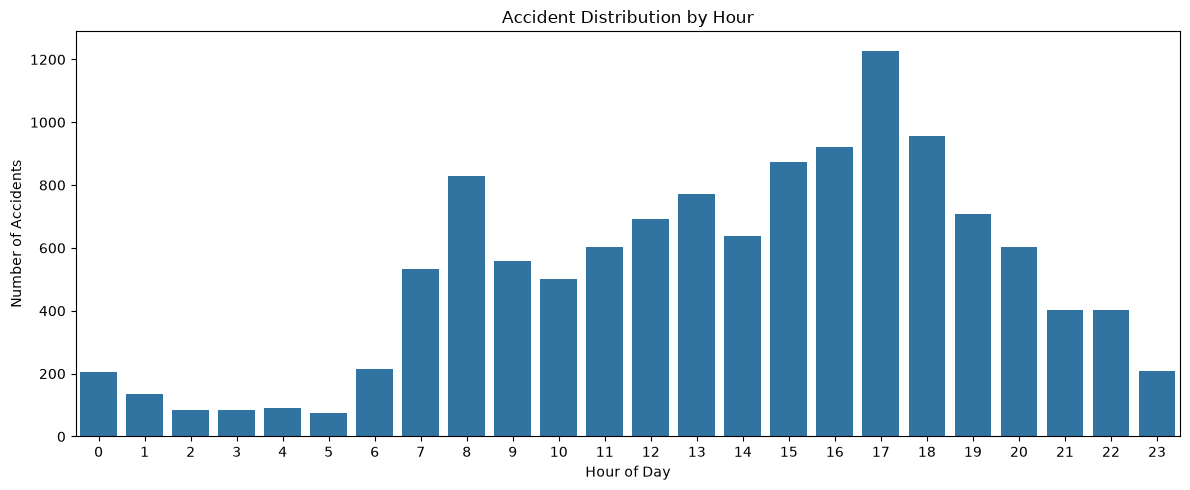

In [ ]:
plt.figure(figsize=(12, 5))
sns.countplot(
    data=df,
    x="Accident_hour"
)
plt.title("Accident Distribution by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Accidents")
plt.tight_layout()
plt.show()

## 19. Feature–Severity Relationship Analysis

The relationship between important accident-related features and accident severity is examined to identify patterns that may contribute to the severity of road accidents.

Both numerical and categorical variables are analyzed to determine their potential relevance for the machine learning model and the subsequent explainable risk analysis.

In [ ]:
numerical_features = [
    "Number_of_vehicles_involved",
    "Number_of_casualties"
]
for column in numerical_features:
    severity_analysis = pd.crosstab(
        df[column],
        df["Accident_severity"],
        normalize="index"
    ) * 100

    print(f"\n{column} - Severity Distribution (%)")
    display(severity_analysis.round(2))


Number_of_vehicles_involved - Severity Distribution (%)


Accident_severity,Fatal injury,Serious Injury,Slight Injury
Number_of_vehicles_involved,,,
1,2.15,26.00,71.84
2,1.25,11.55,87.21
3,0.70,13.39,85.91
4,0.00,10.74,89.26
6,0.00,28.57,71.43
7,0.00,0.00,100.00



Number_of_casualties - Severity Distribution (%)


Accident_severity,Fatal injury,Serious Injury,Slight Injury
Number_of_casualties,,,
1,0.81,14.55,84.64
2,1.05,13.10,85.85
3,1.76,12.76,85.48
4,11.17,11.68,77.16
5,2.90,15.46,81.64
6,0.00,30.34,69.66
7,0.00,0.00,100.00
8,0.00,0.00,100.00


In [ ]:
environmental_features = [
    "Weather_conditions",
    "Road_surface_conditions",
    "Light_conditions",
    "Types_of_Junction"
]
for column in environmental_features:
    severity_analysis = pd.crosstab(
        df[column],
        df["Accident_severity"],
        normalize="index"
    ) * 100
    print(f"\n{column} - Severity Distribution (%)")
    display(severity_analysis.round(2))


Weather_conditions - Severity Distribution (%)


Accident_severity,Fatal injury,Serious Injury,Slight Injury
Weather_conditions,,,
Cloudy,0.00,6.40,93.60
Fog or mist,0.00,10.00,90.00
Normal,1.34,14.65,84.01
Other,0.00,9.46,90.54
Raining,1.73,11.87,86.40
Raining and Windy,0.00,5.00,95.00
Snow,0.00,8.20,91.80
Unknown,0.00,17.47,82.53
Windy,0.00,16.33,83.67



Road_surface_conditions - Severity Distribution (%)


Accident_severity,Fatal injury,Serious Injury,Slight Injury
Road_surface_conditions,,,
Dry,1.30,14.26,84.44
Flood over 3cm. deep,0.00,0.00,100.00
Snow,0.00,5.71,94.29
Wet or damp,1.27,14.02,84.71



Light_conditions - Severity Distribution (%)


Accident_severity,Fatal injury,Serious Injury,Slight Injury
Light_conditions,,,
Darkness - lights lit,2.01,14.15,83.84
Darkness - lights unlit,0.00,17.50,82.50
Darkness - no lighting,2.60,25.52,71.88
Daylight,0.99,13.89,85.12



Types_of_Junction - Severity Distribution (%)


Accident_severity,Fatal injury,Serious Injury,Slight Injury
Types_of_Junction,,,
Crossing,0.55,11.25,88.19
No junction,1.85,15.14,83.01
O Shape,0.61,15.85,83.54
Other,0.45,18.65,80.90
T Shape,0.00,11.67,88.33
Unknown,1.05,13.61,85.34
X Shape,0.00,0.00,100.00
Y Shape,1.17,13.93,84.90


In [ ]:
risk_features = [
    "Cause_of_accident",
    "Type_of_collision",
    "Driving_experience",
    "Type_of_vehicle"
]
for column in risk_features:
    severity_analysis = pd.crosstab(
        df[column],
        df["Accident_severity"],
        normalize="index"
    ) * 100

    print(f"\n{column} - Severity Distribution (%)")
    display(severity_analysis.round(2))


Cause_of_accident - Severity Distribution (%)


Accident_severity,Fatal injury,Serious Injury,Slight Injury
Cause_of_accident,,,
Changing lane to the left,1.09,13.99,84.93
Changing lane to the right,1.27,14.38,84.35
Driving at high speed,1.15,17.82,81.03
Driving carelessly,1.57,14.91,83.52
Driving to the left,1.41,18.66,79.93
Driving under the influence of drugs,1.47,13.53,85.00
Drunk driving,0.00,11.11,88.89
Getting off the vehicle improperly,1.52,14.72,83.76
Improper parking,4.00,8.00,88.00



Type_of_collision - Severity Distribution (%)


Accident_severity,Fatal injury,Serious Injury,Slight Injury
Type_of_collision,,,
Collision with animals,1.17,15.79,83.04
Collision with pedestrians,2.46,15.74,81.81
Collision with roadside objects,1.34,15.23,83.43
Collision with roadside-parked vehicles,0.00,9.26,90.74
Fall from vehicles,0.00,11.76,88.24
Other,0.00,11.54,88.46
Rollover,1.01,13.60,85.39
Unknown,0.00,7.14,92.86
Vehicle with vehicle collision,1.19,13.71,85.10



Driving_experience - Severity Distribution (%)


Accident_severity,Fatal injury,Serious Injury,Slight Injury
Driving_experience,,,
1-2yr,1.20,12.98,85.82
2-5yr,1.76,14.58,83.66
5-10yr,1.22,13.74,85.04
Above 10yr,1.28,14.28,84.44
Below 1yr,0.52,15.42,84.05
No Licence,0.00,11.02,88.98
unknown,3.03,18.18,78.79



Type_of_vehicle - Severity Distribution (%)


Accident_severity,Fatal injury,Serious Injury,Slight Injury
Type_of_vehicle,,,
Automobile,1.25,14.73,84.02
Bajaj,0.00,10.34,89.66
Bicycle,0.00,4.76,95.24
Long lorry,1.04,17.49,81.46
Lorry (11?40Q),1.29,18.30,80.41
Lorry (41?100Q),1.19,12.81,86.00
Motorcycle,1.69,16.38,81.92
Other,1.32,11.42,87.25
Pick up upto 10Q,1.85,16.28,81.87


## 20. Categorical Frequency Analysis

The frequency of categories within categorical features is examined to identify rare categories. Very low-frequency categories may lead to unreliable model estimates and may require grouping during preprocessing.

In [ ]:
categorical_columns = df.select_dtypes(include="object").columns
for column in categorical_columns:
    value_counts = df[column].value_counts(dropna=False)
    rare_values = value_counts[value_counts < 20]
    if len(rare_values) > 0:
        print(f"\n{column}")
        print(rare_values)


Time
Time
13:16:00    19
10:04:00    19
19:25:00    19
11:20:00    19
13:50:00    19
            ..
5:53:00      1
8:34:00      1
22:11:00     1
19:18:00     1
2:47:00      1
Name: count, Length: 893, dtype: int64

Vehicle_driver_relation
Vehicle_driver_relation
Unknown    14
Name: count, dtype: int64

Area_accident_occured
Area_accident_occured
Recreational areas    1
Name: count, dtype: int64

Road_allignment
Road_allignment
Steep grade upward with mountainous terrain    19
Name: count, dtype: int64

Types_of_Junction
Types_of_Junction
X Shape    12
Name: count, dtype: int64

Road_surface_conditions
Road_surface_conditions
Flood over 3cm. deep    2
Name: count, dtype: int64

Weather_conditions
Weather_conditions
Fog or mist    10
Name: count, dtype: int64

Type_of_collision
Type_of_collision
Unknown       14
With Train     9
Name: count, dtype: int64

Vehicle_movement
Vehicle_movement
Parked    10
Name: count, dtype: int64

Work_of_casuality
Work_of_casuality
Unknown    19
Name: cou

C:\Users\Niranjan\AppData\Local\Temp\ipykernel_24376\930180547.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns


## 21. Key EDA Findings

The exploratory data analysis revealed several important characteristics of the road accident dataset. The target variable is highly imbalanced, with Slight Injury representing the majority of observations and Fatal injury representing a small minority class. Several categorical features contain missing or not-applicable values, requiring careful treatment during preprocessing.

The analysis also identified variations in accident severity across the number of vehicles involved, number of casualties, environmental conditions, accident causes, collision types, driving experience, and vehicle types. These observations indicate that multiple accident-related factors may contribute to severity prediction.

The dataset contains no duplicate records. Temporal analysis also indicates variation in accident frequency across different hours of the day. Overall, the EDA provides a basis for feature selection, categorical encoding, missing-value treatment, and class-imbalance handling in the subsequent preprocessing stage.

# Data Preprocessing

The exploratory analysis identified several preprocessing requirements, including handling missing values, transforming temporal information, encoding categorical variables, addressing potential target leakage, and managing the class imbalance present in the accident severity target.

The preprocessing strategy is designed to preserve useful accident-related information while preventing information leakage and ensuring that the resulting dataset is suitable for machine learning.

## 22. Creating a Preprocessing Dataset

A separate copy of the original dataset is created so that the raw dataset remains unchanged throughout the preprocessing process.

In [ ]:
df_processed = df.copy()
print("Preprocessing dataset created.")
print("Shape:", df_processed.shape)

Preprocessing dataset created.
Shape: (12316, 33)


## 23. Target Variable Verification

The target variable `Accident_severity` is verified before preprocessing to ensure that the prediction labels remain unchanged.

In [ ]:
print("Target variable: Accident_severity\n")
print(df_processed["Accident_severity"].value_counts())
print("\nTarget data type:")
print(df_processed["Accident_severity"].dtype)

Target variable: Accident_severity

Accident_severity
Slight Injury     10415
Serious Injury     1743
Fatal injury        158
Name: count, dtype: int64

Target data type:
str


## 24. Removing Potential Target Leakage

The `Casualty_severity` feature is excluded from the predictive feature set because it describes casualty severity associated with the accident and may contain information closely related to the target `Accident_severity`.

Removing this feature helps ensure that the model learns from accident conditions and characteristics rather than relying on outcome-related information that may not be available in a realistic prediction scenario.

In [ ]:
df_processed = df_processed.drop(
    columns=["Casualty_severity"]
)
print("Casualty_severity removed.")
print("New dataset shape:", df_processed.shape)

Casualty_severity removed.
New dataset shape: (12316, 32)


## 25. Temporal Feature Engineering

The original `Time` feature is transformed into meaningful temporal information. The accident hour is retained, while a broader time-of-day category is created to capture differences between morning, afternoon, evening, and night periods.

In [ ]:
def classify_time_period(hour):
    if 5 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 17:
        return "Afternoon"
    elif 17 <= hour < 21:
        return "Evening"
    else:
        return "Night"
df_processed["Time_period"] = df_processed["Accident_hour"].apply(
    classify_time_period
)

print(df_processed[["Time", "Accident_hour", "Time_period"]].head(10))

       Time  Accident_hour Time_period
0  17:02:00             17     Evening
1  17:02:00             17     Evening
2  17:02:00             17     Evening
3   1:06:00              1       Night
4   1:06:00              1       Night
5  14:15:00             14   Afternoon
6  17:30:00             17     Evening
7  17:20:00             17     Evening
8  17:20:00             17     Evening
9  17:20:00             17     Evening


## 26. Removing Redundant Raw Time Information

The original `Time` column is removed after extracting the accident hour and time-of-day category. This avoids retaining a raw string representation of time while preserving its useful temporal information.

In [ ]:
df_processed = df_processed.drop(
    columns=["Time"]
)
print("Raw Time column removed.")
print("Current dataset shape:", df_processed.shape)

Raw Time column removed.
Current dataset shape: (12316, 32)


## 27. Missing Value Treatment

The processed dataset is examined for missing values before imputation. Both standard null values and categorical placeholder values are considered to ensure that missing and not-applicable information are handled appropriately.

In [ ]:
missing_count = df_processed.isnull().sum()
missing_percentage = (missing_count / len(df_processed)) * 100
missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percentage
})
missing_summary = missing_summary[
    missing_summary["Missing Count"] > 0
].sort_values(
    by="Missing Count",
    ascending=False
)
missing_summary

,Missing Count,Missing Percentage
Defect_of_vehicle,4427,35.945112
Service_year_of_vehicle,3928,31.893472
Work_of_casuality,3198,25.966223
Fitness_of_casuality,2635,21.394933
Type_of_vehicle,950,7.713543
Types_of_Junction,887,7.202014
Driving_experience,829,6.731082
Educational_level,741,6.016564
Vehicle_driver_relation,579,4.701202
Owner_of_vehicle,482,3.913608


## 28. Analysis of Not-Applicable Values

Several categorical features contain the value `na`. These values are analyzed separately because they may represent information that is not applicable to a particular accident rather than conventional missing data.

In [ ]:
na_counts = {}
for column in df_processed.select_dtypes(include="object").columns:
    count = (
        df_processed[column]
        .astype(str)
        .str.strip()
        .str.lower()
        .eq("na")
        .sum()
    )
    if count > 0:
        na_counts[column] = count
na_summary = pd.Series(
    na_counts
).sort_values(ascending=False)
print("Literal 'na' value counts:\n")
print(na_summary)

C:\Users\Niranjan\AppData\Local\Temp\ipykernel_24376\1666030202.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for column in df_processed.select_dtypes(include="object").columns:


Literal 'na' value counts:

Casualty_class          4443
Sex_of_casualty         4443
Age_band_of_casualty    4443
dtype: int64


## 29. Inspecting Features with Not-Applicable Values

The distributions of features containing `na` values are examined before deciding how these values should be represented during preprocessing.

In [ ]:
for column in na_summary.index:
    print(f"\n--- {column} ---")
    print(df_processed[column].value_counts(dropna=False).head(10))


--- Casualty_class ---
Casualty_class
Driver or rider    4944
na                 4443
Pedestrian         1649
Passenger          1280
Name: count, dtype: int64

--- Sex_of_casualty ---
Sex_of_casualty
Male      5253
na        4443
Female    2620
Name: count, dtype: int64

--- Age_band_of_casualty ---
Age_band_of_casualty
na          4443
18-30       3145
31-50       2455
Under 18    1035
Over 51      994
5            244
Name: count, dtype: int64


## 30. Missing-Value Handling Strategy

Based on the exploratory analysis, missing information is handled according to its meaning.

For the casualty-related features `Casualty_class`, `Sex_of_casualty`, and `Age_band_of_casualty`, the value `na` occurs consistently across the same observations and is treated as a meaningful **Not Applicable** category.

For genuine missing values represented by Pandas null values, the categorical value **Unknown** is used. This approach avoids unnecessary row deletion and preserves the information contained in incomplete accident records.

In [ ]:
not_applicable_columns = [
    "Casualty_class",
    "Sex_of_casualty",
    "Age_band_of_casualty"
]
for column in not_applicable_columns:
    df_processed[column] = df_processed[column].replace(
        "na",
        "Not Applicable"
    )
print("Converted 'na' values to 'Not Applicable'.")

Converted 'na' values to 'Not Applicable'.


## 31. Handling Genuine Missing Categorical Values

Remaining missing values in categorical features are replaced with the category `Unknown`. This preserves the corresponding accident records while explicitly indicating that the information was unavailable.

In [ ]:
categorical_columns = df_processed.select_dtypes(
    include=["object", "string"]
).columns
for column in categorical_columns:
    df_processed[column] = df_processed[column].fillna("Unknown")
print("Genuine categorical missing values replaced with 'Unknown'.")

Genuine categorical missing values replaced with 'Unknown'.


## 32. Verification of Missing-Value Treatment

The dataset is checked again to confirm that all standard missing values have been handled successfully.

In [ ]:
remaining_missing = df_processed.isnull().sum()
remaining_missing = remaining_missing[
    remaining_missing > 0
]
if remaining_missing.empty:
    print("No standard missing values remain.")
else:
    print("Remaining missing values:")
    print(remaining_missing)

No standard missing values remain.


## 33. Verification of Not-Applicable Categories

The newly created `Not Applicable` category is verified for the casualty-related features to ensure that the original semantic information has been preserved.

In [ ]:
for column in not_applicable_columns:
    count = (
        df_processed[column]
        .eq("Not Applicable")
        .sum()
    )
    print(f"{column}: {count} Not Applicable records")

Casualty_class: 4443 Not Applicable records
Sex_of_casualty: 4443 Not Applicable records
Age_band_of_casualty: 4443 Not Applicable records


## 34. Separating Features and Target

The dataset is divided into predictor variables and the target variable. `Accident_severity` is the target that the machine learning models will learn to predict.

In [ ]:
X = df_processed.drop(
    columns=["Accident_severity"]
)
y = df_processed["Accident_severity"]
print("Feature dataset shape:", X.shape)
print("Target shape:", y.shape)

Feature dataset shape: (12316, 31)
Target shape: (12316,)


## 35. Target Variable Encoding

The categorical accident severity labels are converted into numerical class labels for machine learning.

The original class names are retained through a label mapping so that model predictions can later be converted back into meaningful severity categories.

In [ ]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
print("Target class mapping:")
for label, encoded_value in zip(
    label_encoder.classes_,
    label_encoder.transform(label_encoder.classes_)
):
    print(f"{label} -> {encoded_value}")

Target class mapping:
Fatal injury -> 0
Serious Injury -> 1
Slight Injury -> 2


## 36. Encoded Target Distribution

The distribution of the encoded target classes is verified to ensure that the class imbalance identified during EDA is preserved correctly before model training.

In [ ]:
encoded_distribution = pd.Series(
    y_encoded
).value_counts().sort_index()
print("Encoded target distribution:")
print(encoded_distribution)

Encoded target distribution:
0      158
1     1743
2    10415
Name: count, dtype: int64


## 37. Train-Test Split

The preprocessed dataset is divided into training and testing subsets before fitting the feature encoders and machine learning models.

A stratified split is used to preserve the proportion of each accident severity class in both subsets. This is particularly important because the target variable is highly imbalanced.

In [ ]:

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)
print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)
print("\nTraining target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training feature shape: (9852, 31)
Testing feature shape: (2464, 31)

Training target shape: (9852,)
Testing target shape: (2464,)


## 38. Verification of Class Distribution After Splitting

The class distribution in the training and testing sets is compared to verify that stratified sampling has preserved the original proportion of accident severity classes.

In [ ]:
train_distribution = pd.Series(
    y_train
).value_counts().sort_index()
test_distribution = pd.Series(
    y_test
).value_counts().sort_index()
distribution_comparison = pd.DataFrame({
    "Training Count": train_distribution,
    "Testing Count": test_distribution,
    "Original Count": pd.Series(y_encoded).value_counts().sort_index()
})
distribution_comparison.index = label_encoder.inverse_transform(
    distribution_comparison.index
)
distribution_comparison

,Training Count,Testing Count,Original Count
Fatal injury,127,31,158
Serious Injury,1394,349,1743
Slight Injury,8331,2084,10415


## 39. Identifying Numerical and Categorical Features

The predictor variables are separated into numerical and categorical feature groups. Different preprocessing techniques will be applied to each type of feature.

In [ ]:
numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()
categorical_features = X_train.select_dtypes(
    include=["object", "string"]
).columns.tolist()
print("Numerical features:")
print(numerical_features)
print("\nNumber of numerical features:", len(numerical_features))
print("\nNumber of categorical features:", len(categorical_features))
print("\nCategorical features:")
print(categorical_features)

Numerical features:
['Number_of_vehicles_involved', 'Number_of_casualties']

Number of numerical features: 2

Number of categorical features: 28

Categorical features:
['Day_of_week', 'Age_band_of_driver', 'Sex_of_driver', 'Educational_level', 'Vehicle_driver_relation', 'Driving_experience', 'Type_of_vehicle', 'Owner_of_vehicle', 'Service_year_of_vehicle', 'Defect_of_vehicle', 'Area_accident_occured', 'Lanes_or_Medians', 'Road_allignment', 'Types_of_Junction', 'Road_surface_type', 'Road_surface_conditions', 'Light_conditions', 'Weather_conditions', 'Type_of_collision', 'Vehicle_movement', 'Casualty_class', 'Sex_of_casualty', 'Age_band_of_casualty', 'Work_of_casuality', 'Fitness_of_casuality', 'Pedestrian_movement', 'Cause_of_accident', 'Time_period']


## 40. Categorical Feature Cardinality

The number of unique categories in each categorical feature is examined before encoding. This helps identify the expected dimensionality after one-hot encoding and highlights features with relatively high cardinality.

In [ ]:
cardinality = pd.DataFrame({
    "Feature": categorical_features,
    "Unique Categories": [
        X_train[column].nunique()
        for column in categorical_features
    ]
}).sort_values(
    by="Unique Categories",
    ascending=False
)
cardinality

,Feature,Unique Categories
26,Cause_of_accident,20
6,Type_of_vehicle,18
19,Vehicle_movement,13
10,Area_accident_occured,13
12,Road_allignment,10
18,Type_of_collision,10
17,Weather_conditions,9
25,Pedestrian_movement,9
5,Driving_experience,8
13,Types_of_Junction,8


## 41. Feature Preprocessing Pipeline

Numerical and categorical features require different preprocessing techniques. Numerical features are standardized, while categorical features are converted into numerical representations using One-Hot Encoding.

The preprocessing transformations are fitted using only the training data and subsequently applied to the testing data to prevent data leakage.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

## 42. Numerical and Categorical Transformation

Standardization is applied to numerical features so that they have a comparable scale. Categorical features are transformed using One-Hot Encoding, with unseen categories in the test data safely ignored.

In [ ]:
numerical_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)
print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


## 43. Fitting the Preprocessing Pipeline

The preprocessing pipeline is fitted exclusively on the training data. This ensures that information from the testing dataset does not influence the learned preprocessing parameters.

In [ ]:
preprocessor.fit(X_train)
print("Preprocessing pipeline fitted successfully.")

Preprocessing pipeline fitted successfully.


## 44. Transforming Training and Testing Data

The fitted preprocessing pipeline is applied to both the training and testing datasets. The same transformations learned from the training data are therefore consistently applied to unseen test data.

In [ ]:
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)
print("Training processed shape:", X_train_processed.shape)
print("Testing processed shape:", X_test_processed.shape)

Training processed shape: (9852, 212)
Testing processed shape: (2464, 212)


## 45. Verification of Processed Feature Matrix

The transformed feature matrices are inspected to verify that the preprocessing stage has successfully converted the original mixed-type dataset into a numerical representation suitable for machine learning.

In [ ]:
print("Training matrix:")
print("Shape:", X_train_processed.shape)
print("Data type:", X_train_processed.dtype)
print("\nTesting matrix:")
print("Shape:", X_test_processed.shape)
print("Data type:", X_test_processed.dtype)

Training matrix:
Shape: (9852, 212)
Data type: float64

Testing matrix:
Shape: (2464, 212)
Data type: float64


## 46. Extracting Processed Feature Names

The names of the transformed features are extracted from the preprocessing pipeline. These feature names will later be used to interpret model feature importance and identify factors associated with accident severity.

In [ ]:
feature_names = preprocessor.get_feature_names_out()
print("Number of processed features:", len(feature_names))
print("\nFirst 20 processed features:")
print(feature_names[:20])

Number of processed features: 212

First 20 processed features:
['num__Number_of_vehicles_involved' 'num__Number_of_casualties'
 'cat__Day_of_week_Friday' 'cat__Day_of_week_Monday'
 'cat__Day_of_week_Saturday' 'cat__Day_of_week_Sunday'
 'cat__Day_of_week_Thursday' 'cat__Day_of_week_Tuesday'
 'cat__Day_of_week_Wednesday' 'cat__Age_band_of_driver_18-30'
 'cat__Age_band_of_driver_31-50' 'cat__Age_band_of_driver_Over 51'
 'cat__Age_band_of_driver_Under 18' 'cat__Age_band_of_driver_Unknown'
 'cat__Sex_of_driver_Female' 'cat__Sex_of_driver_Male'
 'cat__Sex_of_driver_Unknown' 'cat__Educational_level_Above high school'
 'cat__Educational_level_Elementary school'
 'cat__Educational_level_High school']


## 47. Creating the Processed Feature DataFrame

The transformed training and testing matrices are converted into Pandas DataFrames with their corresponding feature names. This provides a readable representation of the processed dataset and facilitates subsequent analysis.

In [ ]:
X_train_processed_df = pd.DataFrame(
    X_train_processed,
    columns=feature_names,
    index=X_train.index
)
X_test_processed_df = pd.DataFrame(
    X_test_processed,
    columns=feature_names,
    index=X_test.index
)
print("Processed training DataFrame shape:", X_train_processed_df.shape)
print("Processed testing DataFrame shape:", X_test_processed_df.shape)

Processed training DataFrame shape: (9852, 212)
Processed testing DataFrame shape: (2464, 212)


## 48. Training Class Imbalance Analysis

The class distribution of the training dataset is analyzed before model development. Since the accident severity target is highly imbalanced, the minority classes may be poorly represented during model training.

Class weighting will initially be investigated as a strategy to reduce the bias toward the majority class without altering the testing dataset.

In [ ]:
train_class_counts = pd.Series(y_train).value_counts().sort_index()
train_class_percentages = (
    pd.Series(y_train)
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)
class_distribution = pd.DataFrame({
    "Class Count": train_class_counts,
    "Percentage": train_class_percentages
})
class_distribution.index = label_encoder.inverse_transform(
    class_distribution.index
)
class_distribution

,Class Count,Percentage
Fatal injury,127,1.29
Serious Injury,1394,14.15
Slight Injury,8331,84.56


## 49. Class Weight Calculation

Class weights are calculated based on the training data to give greater importance to minority severity classes during model training.

This approach allows the model to penalize incorrect predictions of minority classes more strongly while preserving the original training observations.

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
classes = np.unique(y_train)
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)
class_weight_dict = dict(
    zip(classes, class_weights)
)
print("Calculated class weights:")
for class_id, weight in class_weight_dict.items():
    class_name = label_encoder.inverse_transform([class_id])[0]
    print(f"{class_name}: {weight:.4f}")

Calculated class weights:
Fatal injury: 25.8583
Serious Injury: 2.3558
Slight Injury: 0.3942


## 50. Training Class Distribution Visualization

The training class distribution is visualized to clearly demonstrate the severity imbalance that must be considered during model development.

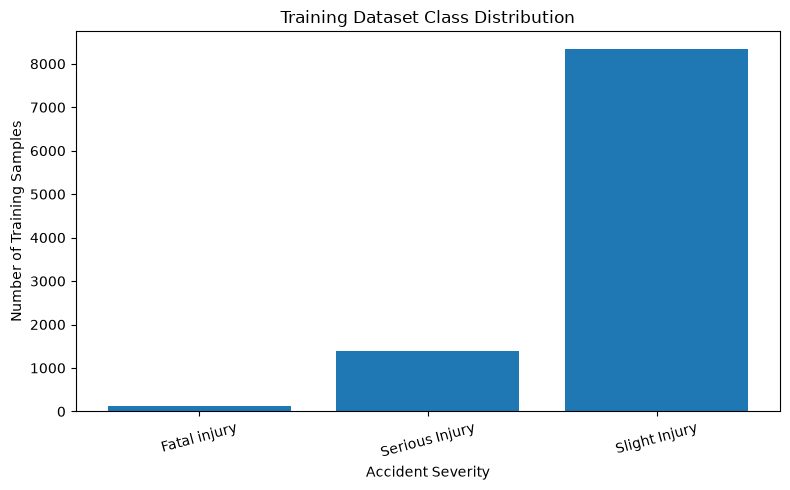

In [ ]:
plot_labels = label_encoder.inverse_transform(
    train_class_counts.index
)
plt.figure(figsize=(8, 5))
plt.bar(
    plot_labels,
    train_class_counts.values
)
plt.xlabel("Accident Severity")
plt.ylabel("Number of Training Samples")
plt.title("Training Dataset Class Distribution")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 51. Baseline Random Forest Model

A Random Forest classifier is developed as the first baseline machine learning model.

Class weighting is incorporated to reduce the influence of the severe class imbalance observed in the accident severity target. The model is trained only on the processed training dataset.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)
rf_model.fit(
    X_train_processed,
    y_train
)
print("Random Forest model trained successfully.")

Random Forest model trained successfully.


## 52. Generating Test Predictions

The trained Random Forest model is used to predict accident severity for the unseen testing dataset.

In [ ]:
y_pred = rf_model.predict(
    X_test_processed
)
print("Predictions generated successfully.")
print("Number of predictions:", len(y_pred))

Predictions generated successfully.
Number of predictions: 2464


## 53. Random Forest Model Evaluation

The baseline model is evaluated using accuracy, precision, recall, and F1-score.

Because the target variable is highly imbalanced, macro-averaged metrics are also reported so that the performance across all severity classes is considered equally.

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
accuracy = accuracy_score(
    y_test,
    y_pred
)
precision_macro = precision_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)
recall_macro = recall_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)
f1_macro = f1_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)
print(f"Accuracy:          {accuracy:.4f}")
print(f"Macro Precision:   {precision_macro:.4f}")
print(f"Macro Recall:      {recall_macro:.4f}")
print(f"Macro F1-score:    {f1_macro:.4f}")

Accuracy:          0.8462
Macro Precision:   0.4502
Macro Recall:      0.3462
Macro F1-score:    0.3334


## 54. Detailed Classification Report

A class-wise classification report is generated to examine how effectively the model predicts each accident severity category, particularly the minority Fatal injury class.

In [ ]:
from sklearn.metrics import classification_report
print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

                precision    recall  f1-score   support

  Fatal injury       0.00      0.00      0.00        31
Serious Injury       0.50      0.05      0.08       349
 Slight Injury       0.85      0.99      0.92      2084

      accuracy                           0.85      2464
     macro avg       0.45      0.35      0.33      2464
  weighted avg       0.79      0.85      0.79      2464



## 55. Confusion Matrix

The confusion matrix is used to visualize the correct and incorrect predictions made by the Random Forest model across the three accident severity classes.

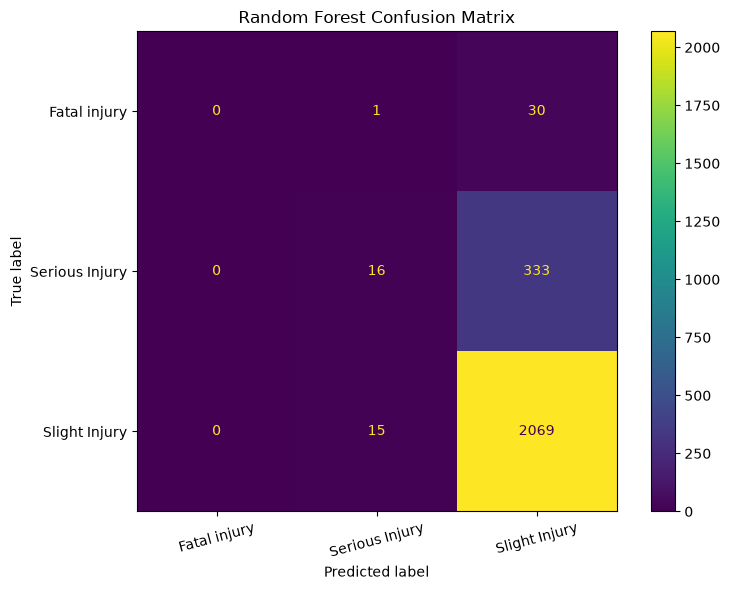

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(
    y_test,
    y_pred
)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(
    ax=ax,
    values_format="d"
)
plt.title("Random Forest Confusion Matrix")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 56. SMOTE-Based Class Imbalance Handling

The baseline Random Forest model showed strong performance for the majority Slight Injury class but poor recall for the minority Serious Injury and Fatal injury classes.

To investigate whether improving the representation of minority classes can improve model performance, SMOTE (Synthetic Minority Over-sampling Technique) is applied to the training data.

SMOTE is applied only to the training dataset. The testing dataset remains unchanged to provide an unbiased evaluation of model performance on the original class distribution.

In [ ]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(
    random_state=42
)
X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)
print("Original training shape:", X_train_processed.shape)
print("SMOTE training shape:", X_train_smote.shape)

Original training shape: (9852, 212)
SMOTE training shape: (24993, 212)


## 57. Verification of SMOTE Class Distribution

The class distribution after SMOTE is examined to verify that the minority severity classes have been balanced in the training dataset.

In [ ]:
before_smote = pd.Series(y_train).value_counts().sort_index()
after_smote = pd.Series(y_train_smote).value_counts().sort_index()
smote_comparison = pd.DataFrame({
    "Before SMOTE": before_smote,
    "After SMOTE": after_smote
})
smote_comparison.index = label_encoder.inverse_transform(
    smote_comparison.index
)
smote_comparison

,Before SMOTE,After SMOTE
Fatal injury,127,8331
Serious Injury,1394,8331
Slight Injury,8331,8331


## 58. Random Forest with SMOTE

A second Random Forest model is trained using the SMOTE-balanced training dataset.

The same testing dataset is retained so that the performance of the SMOTE-based model can be directly compared with the class-weighted baseline model.

In [ ]:
rf_smote = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)
rf_smote.fit(
    X_train_smote,
    y_train_smote
)
print("SMOTE-based Random Forest trained successfully.")

SMOTE-based Random Forest trained successfully.


## 59. SMOTE Random Forest Predictions

The SMOTE-based Random Forest is evaluated on the original, untouched testing dataset.

In [ ]:
y_pred_smote = rf_smote.predict(
    X_test_processed
)
print("SMOTE predictions generated successfully.")

SMOTE predictions generated successfully.


## 60. SMOTE Random Forest Evaluation

The SMOTE-based model is evaluated using accuracy, macro precision, macro recall, and macro F1-score.

Macro-averaged metrics are emphasized because all accident severity classes should be considered equally important, especially the minority Fatal injury class.

In [ ]:
accuracy_smote = accuracy_score(
    y_test,
    y_pred_smote
)
precision_smote = precision_score(
    y_test,
    y_pred_smote,
    average="macro",
    zero_division=0
)
recall_smote = recall_score(
    y_test,
    y_pred_smote,
    average="macro",
    zero_division=0
)
f1_smote = f1_score(
    y_test,
    y_pred_smote,
    average="macro",
    zero_division=0
)
print(f"Accuracy:          {accuracy_smote:.4f}")
print(f"Macro Precision:   {precision_smote:.4f}")
print(f"Macro Recall:      {recall_smote:.4f}")
print(f"Macro F1-score:    {f1_smote:.4f}")

Accuracy:          0.8462
Macro Precision:   0.6154
Macro Recall:      0.3343
Macro F1-score:    0.3075


## 61. SMOTE Classification Report

The class-wise precision, recall, and F1-score of the SMOTE-based model are examined to determine whether minority-class prediction has improved compared with the baseline Random Forest.

In [ ]:
print(
    classification_report(
        y_test,
        y_pred_smote,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

                precision    recall  f1-score   support

  Fatal injury       0.00      0.00      0.00        31
Serious Injury       1.00      0.00      0.01       349
 Slight Injury       0.85      1.00      0.92      2084

      accuracy                           0.85      2464
     macro avg       0.62      0.33      0.31      2464
  weighted avg       0.86      0.85      0.78      2464



## 62. SMOTE Confusion Matrix

The confusion matrix is visualized to examine how the SMOTE-based model distributes predictions across the three accident severity classes.

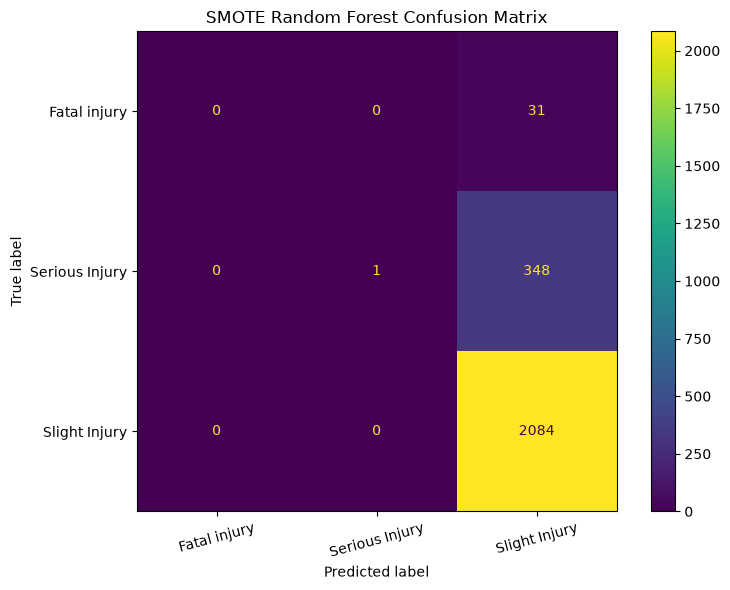

In [86]:
cm_smote = confusion_matrix(
    y_test,
    y_pred_smote
)
disp_smote = ConfusionMatrixDisplay(
    confusion_matrix=cm_smote,
    display_labels=label_encoder.classes_
)
fig, ax = plt.subplots(figsize=(8, 6)) 
disp_smote.plot(
    ax=ax,
    values_format="d"
)

plt.title("SMOTE Random Forest Confusion Matrix")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 63. Comparison of Class Imbalance Strategies

Two approaches were evaluated for handling the severe class imbalance in accident severity:

1. Class-weighted Random Forest
2. SMOTE-based Random Forest

The models were evaluated on the same untouched testing dataset using accuracy, macro precision, macro recall, and macro F1-score.

Macro-averaged metrics are emphasized because the objective is to achieve balanced performance across all accident severity classes rather than optimizing performance only for the majority Slight Injury class.

In [87]:
model_comparison = pd.DataFrame({
    "Model": [
        "Class-Weighted Random Forest",
        "SMOTE + Random Forest"
    ],
    "Accuracy": [
        accuracy,
        accuracy_smote
    ],
    "Macro Precision": [
        precision_macro,
        precision_smote
    ],
    "Macro Recall": [
        recall_macro,
        recall_smote
    ],
    "Macro F1": [
        f1_macro,
        f1_smote
    ]
})
model_comparison.round(4)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Class-Weighted Random Forest,0.8462,0.4502,0.3462,0.3334
1,SMOTE + Random Forest,0.8462,0.6154,0.3343,0.3075


## 64. Model Performance Comparison

The performance of the two imbalance-handling approaches is visualized to identify the more suitable baseline strategy for subsequent analysis.

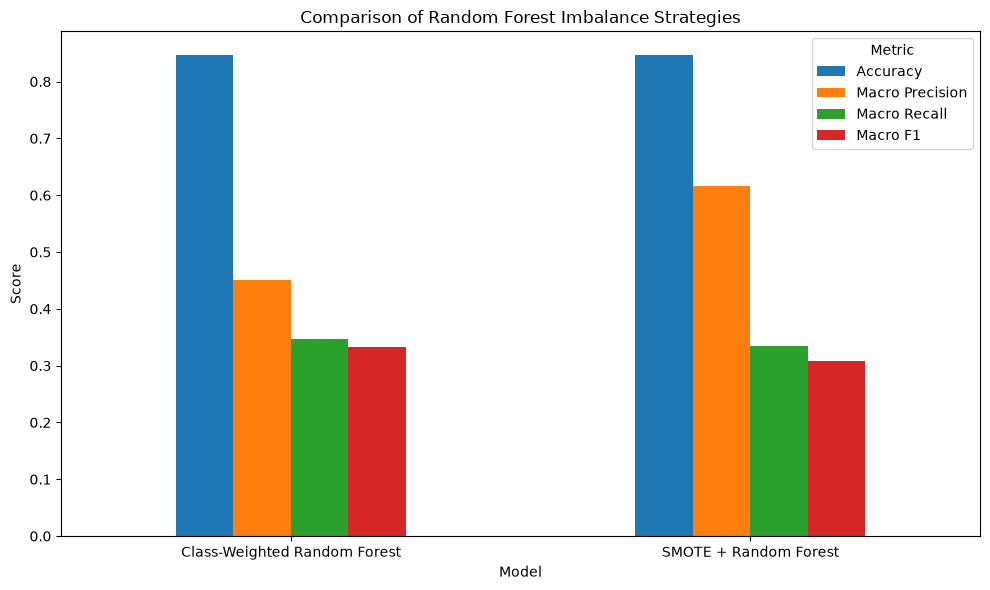

In [88]:
metrics = [
    "Accuracy",
    "Macro Precision",
    "Macro Recall",
    "Macro F1"
]
comparison_plot = model_comparison.set_index("Model")[metrics]
comparison_plot.plot(
    kind="bar",
    figsize=(10, 6)
)
plt.xlabel("Model")
plt.ylabel("Score")
plt.title("Comparison of Random Forest Imbalance Strategies")
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

## 65. Baseline Model Selection

Based on the preliminary evaluation, the class-weighted Random Forest is selected as the current baseline model because it achieves a higher Macro F1-score and Macro Recall than the SMOTE-based Random Forest.

Although both approaches achieve similar overall accuracy, the class-weighted model provides better balanced performance across the severity classes.

The inability of both models to correctly identify the Fatal injury class highlights the difficulty caused by the extremely small minority class and will be considered in further model development.

## 66. Feature Importance Analysis

Feature importance from the class-weighted Random Forest is analyzed to identify the accident characteristics that contribute most strongly to the model's predictions.

These important features will form the basis of the RoadSafe risk analysis component.


In [89]:
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
})
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)
feature_importance.head(20)

,Feature,Importance
1,num__Number_of_casualties,0.056584
0,num__Number_of_vehicles_involved,0.031587
9,cat__Age_band_of_driver_18-30,0.011951
100,cat__Types_of_Junction_No junction,0.011744
166,cat__Work_of_casuality_Driver,0.011666
10,cat__Age_band_of_driver_31-50,0.011429
106,cat__Types_of_Junction_Y Shape,0.011343
84,cat__Lanes_or_Medians_Two-way (divided with br...,0.011135
36,cat__Type_of_vehicle_Automobile,0.011091
211,cat__Time_period_Night,0.010952


## 67. Top Accident Risk Factors

The twenty most influential processed features are visualized to identify the factors that have the greatest influence on the Random Forest model.

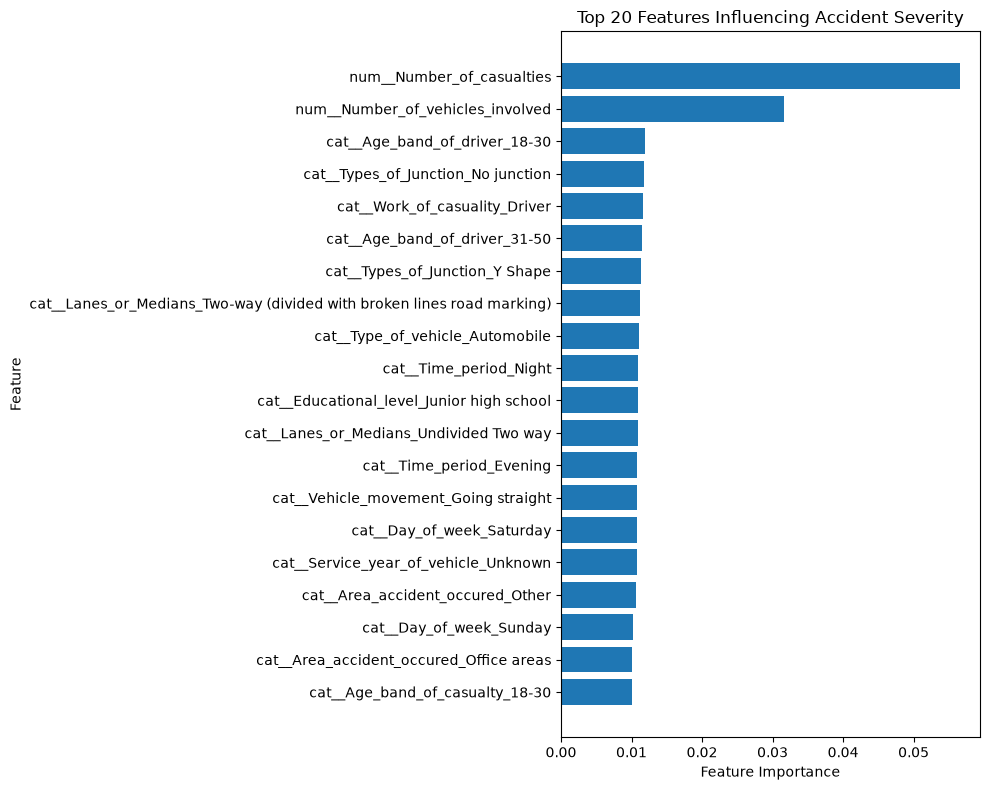

In [90]:
top_features = feature_importance.head(20).sort_values(
    by="Importance"
)
plt.figure(figsize=(10, 8))
plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 20 Features Influencing Accident Severity")
plt.tight_layout()
plt.show()

## 68. Risk Factor Summary

The ranked feature-importance table is retained as a reference for the explainable risk-analysis component of RoadSafe.

In [91]:
top_20_features = feature_importance.head(20).reset_index(
    drop=True
)
top_20_features

,Feature,Importance
0,num__Number_of_casualties,0.056584
1,num__Number_of_vehicles_involved,0.031587
2,cat__Age_band_of_driver_18-30,0.011951
3,cat__Types_of_Junction_No junction,0.011744
4,cat__Work_of_casuality_Driver,0.011666
5,cat__Age_band_of_driver_31-50,0.011429
6,cat__Types_of_Junction_Y Shape,0.011343
7,cat__Lanes_or_Medians_Two-way (divided with br...,0.011135
8,cat__Type_of_vehicle_Automobile,0.011091
9,cat__Time_period_Night,0.010952


## 69. XGBoost Model

Extreme Gradient Boosting (XGBoost) is evaluated as an alternative ensemble learning approach.

Unlike Random Forest, which builds trees independently, XGBoost builds trees sequentially, with each new tree attempting to correct errors made by previous trees.

The model is evaluated using the same untouched testing dataset and the same macro-averaged metrics used for the Random Forest experiments.

In [92]:
from xgboost import XGBClassifier
print("XGBoost imported successfully.")

XGBoost imported successfully.


## 70. Training the XGBoost Model

The XGBoost classifier is trained using the processed training dataset.

Class imbalance is incorporated through sample weighting so that minority severity classes receive greater importance during model optimization.

In [93]:
sample_weights = np.array([
    class_weight_dict[class_id]
    for class_id in y_train
])
print("Sample weights calculated.")
print("Number of weighted training samples:", len(sample_weights))

Sample weights calculated.
Number of weighted training samples: 9852


In [94]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(
    X_train_processed,
    y_train,
    sample_weight=sample_weights
)
print("XGBoost model trained successfully.")

XGBoost model trained successfully.


## 71. XGBoost Predictions

The trained XGBoost model is used to predict accident severity for the unseen testing dataset.

In [95]:
y_pred_xgb = xgb_model.predict(
    X_test_processed
)
print("XGBoost predictions generated successfully.")

XGBoost predictions generated successfully.


## 72. XGBoost Model Evaluation

The XGBoost model is evaluated using accuracy, macro precision, macro recall, and macro F1-score.

Macro-averaged metrics are emphasized because the dataset contains severe class imbalance.

In [96]:
accuracy_xgb = accuracy_score(
    y_test,
    y_pred_xgb
)
precision_xgb = precision_score(
    y_test,
    y_pred_xgb,
    average="macro",
    zero_division=0
)
recall_xgb = recall_score(
    y_test,
    y_pred_xgb,
    average="macro",
    zero_division=0
)
f1_xgb = f1_score(
    y_test,
    y_pred_xgb,
    average="macro",
    zero_division=0
)
print(f"Accuracy:          {accuracy_xgb:.4f}")
print(f"Macro Precision:   {precision_xgb:.4f}")
print(f"Macro Recall:      {recall_xgb:.4f}")
print(f"Macro F1-score:    {f1_xgb:.4f}")

Accuracy:          0.7378
Macro Precision:   0.4225
Macro Recall:      0.4426
Macro F1-score:    0.4297


## 73. XGBoost Classification Report

The class-wise performance of XGBoost is examined to determine whether the model improves prediction of Serious Injury and Fatal injury compared with the Random Forest models.

In [97]:
print(
    classification_report(
        y_test,
        y_pred_xgb,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

                precision    recall  f1-score   support

  Fatal injury       0.16      0.19      0.18        31
Serious Injury       0.24      0.32      0.27       349
 Slight Injury       0.87      0.82      0.84      2084

      accuracy                           0.74      2464
     macro avg       0.42      0.44      0.43      2464
  weighted avg       0.77      0.74      0.75      2464



## 74. XGBoost Confusion Matrix

The confusion matrix is used to examine the distribution of correct and incorrect XGBoost predictions across the three accident severity classes.

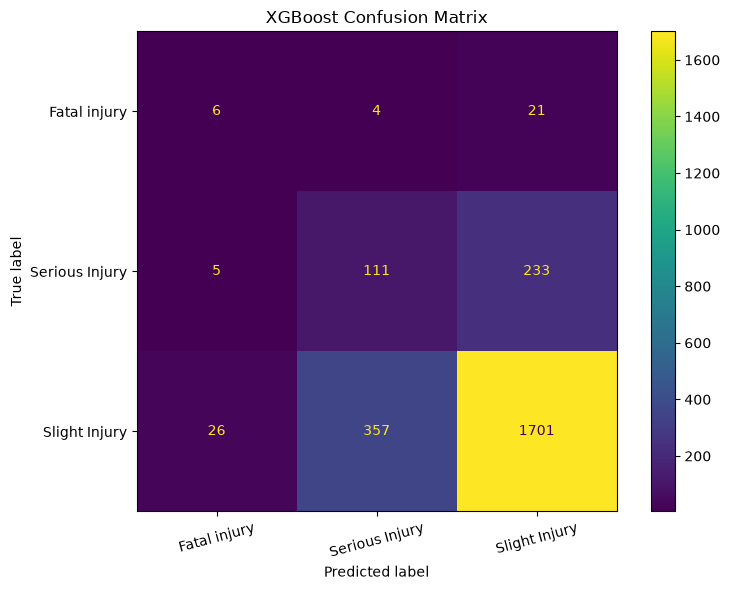

In [98]:
cm_xgb = confusion_matrix(
    y_test,
    y_pred_xgb
)
disp_xgb = ConfusionMatrixDisplay(
    confusion_matrix=cm_xgb,
    display_labels=label_encoder.classes_
)
fig, ax = plt.subplots(figsize=(8, 6))
disp_xgb.plot(
    ax=ax,
    values_format="d"
)
plt.title("XGBoost Confusion Matrix")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 75. Overall Model Comparison

The three evaluated approaches are compared using accuracy, macro precision, macro recall, and macro F1-score.

Although the class-weighted Random Forest achieves higher overall accuracy, XGBoost achieves substantially better macro-averaged recall and F1-score while also improving detection of the minority Fatal injury class.

Since accident severity prediction requires meaningful performance across all severity classes, particularly severe accidents, Macro F1 and minority-class recall are prioritized over accuracy alone.

In [99]:
final_model_comparison = pd.DataFrame({
    "Model": [
        "Class-Weighted Random Forest",
        "SMOTE + Random Forest",
        "Weighted XGBoost"
    ],
    "Accuracy": [
        accuracy,
        accuracy_smote,
        accuracy_xgb
    ],
    "Macro Precision": [
        precision_macro,
        precision_smote,
        precision_xgb
    ],
    "Macro Recall": [
        recall_macro,
        recall_smote,
        recall_xgb
    ],
    "Macro F1": [
        f1_macro,
        f1_smote,
        f1_xgb
    ]
})
final_model_comparison.round(4)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Class-Weighted Random Forest,0.8462,0.4502,0.3462,0.3334
1,SMOTE + Random Forest,0.8462,0.6154,0.3343,0.3075
2,Weighted XGBoost,0.7378,0.4225,0.4426,0.4297


## 76. Model Performance Comparison

The performance of all evaluated models is visualized to identify the most suitable approach for accident severity prediction.

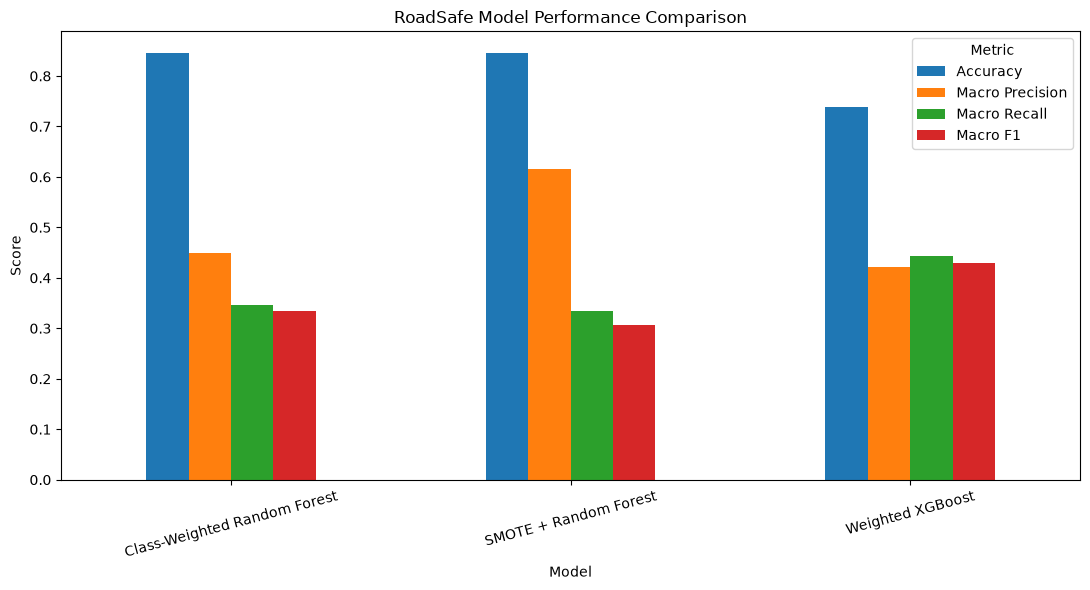

In [100]:
metrics = [
    "Accuracy",
    "Macro Precision",
    "Macro Recall",
    "Macro F1"
]
final_model_comparison.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(11, 6)
)
plt.xlabel("Model")
plt.ylabel("Score")
plt.title("RoadSafe Model Performance Comparison")
plt.xticks(rotation=15)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

## 77. Final Model Selection

Based on the preliminary experiments, the weighted XGBoost model is selected as the current candidate for the RoadSafe prediction system.

While its overall accuracy is lower than the Random Forest baseline, XGBoost provides substantially better Macro Recall and Macro F1-score and is able to identify a portion of the Fatal injury cases.

Further optimization and validation will be performed before the final model is deployed.

In [101]:
final_model = xgb_model
final_predictions = y_pred_xgb
print("Current candidate model: Weighted XGBoost")
print(f"Macro F1-score: {f1_xgb:.4f}")
print(f"Macro Recall: {recall_xgb:.4f}")

Current candidate model: Weighted XGBoost
Macro F1-score: 0.4297
Macro Recall: 0.4426


## 78. XGBoost Hyperparameter Tuning

The preliminary XGBoost model achieved better balanced performance than the Random Forest models, particularly for the minority severity classes. However, its performance can potentially be improved through hyperparameter optimization.

A controlled hyperparameter search is performed to identify a model configuration that improves Macro F1-score while maintaining reasonable performance across all accident severity classes.

## 79. Hyperparameter Search Space

A limited hyperparameter search space is defined for the XGBoost model. The selected parameters control model complexity, learning rate, number of boosting rounds, and the proportion of training features and samples used by each tree.

In [102]:
param_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}
print("Hyperparameter search space created.")

Hyperparameter search space created.


## 80. Randomized Hyperparameter Search

Randomized search is used to efficiently explore the defined XGBoost hyperparameter space. Macro F1-score is used as the optimization metric because the dataset contains substantial class imbalance and balanced performance across severity classes is more important than accuracy alone.

In [103]:
from sklearn.model_selection import RandomizedSearchCV
xgb_tuning_model = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)
random_search = RandomizedSearchCV(
    estimator=xgb_tuning_model,
    param_distributions=param_grid,
    n_iter=20,
    scoring="f1_macro",
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)
random_search.fit(
    X_train_processed,
    y_train,
    sample_weight=sample_weights
)
print("Hyperparameter tuning completed.")

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Hyperparameter tuning completed.


## 81. Best XGBoost Hyperparameters

The hyperparameter configuration that achieved the highest cross-validated Macro F1-score is identified and recorded for the optimized RoadSafe model.

In [104]:
print("Best XGBoost parameters:\n")
for parameter, value in random_search.best_params_.items():
    print(f"{parameter}: {value}")

print("\nBest cross-validation Macro F1-score:")
print(round(random_search.best_score_, 4))

Best XGBoost parameters:

subsample: 0.8
n_estimators: 200
max_depth: 3
learning_rate: 0.03
colsample_bytree: 0.8

Best cross-validation Macro F1-score:
0.5256


## 82. Optimized XGBoost Evaluation

The best XGBoost configuration identified through cross-validation is evaluated on the untouched testing dataset.

The same evaluation metrics used for the baseline models are retained to allow a fair comparison.

In [105]:
best_xgb_model = random_search.best_estimator_
y_pred_tuned = best_xgb_model.predict(
    X_test_processed
)
accuracy_tuned = accuracy_score(
    y_test,
    y_pred_tuned
)
precision_tuned = precision_score(
    y_test,
    y_pred_tuned,
    average="macro",
    zero_division=0
)
recall_tuned = recall_score(
    y_test,
    y_pred_tuned,
    average="macro",
    zero_division=0
)
f1_tuned = f1_score(
    y_test,
    y_pred_tuned,
    average="macro",
    zero_division=0
)
print(f"Accuracy:          {accuracy_tuned:.4f}")
print(f"Macro Precision:   {precision_tuned:.4f}")
print(f"Macro Recall:      {recall_tuned:.4f}")
print(f"Macro F1-score:    {f1_tuned:.4f}")

Accuracy:          0.6420
Macro Precision:   0.3936
Macro Recall:      0.4910
Macro F1-score:    0.3922


## 83. Optimized XGBoost Classification Report

The class-wise performance of the optimized XGBoost model is examined to determine whether hyperparameter tuning improves the detection of Serious Injury and Fatal injury cases.

In [106]:
print(
    classification_report(
        y_test,
        y_pred_tuned,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

                precision    recall  f1-score   support

  Fatal injury       0.05      0.32      0.09        31
Serious Injury       0.24      0.48      0.32       349
 Slight Injury       0.89      0.67      0.77      2084

      accuracy                           0.64      2464
     macro avg       0.39      0.49      0.39      2464
  weighted avg       0.79      0.64      0.69      2464



## 84. Optimized XGBoost Confusion Matrix

The confusion matrix of the optimized XGBoost model is visualized to examine prediction errors across all accident severity classes.

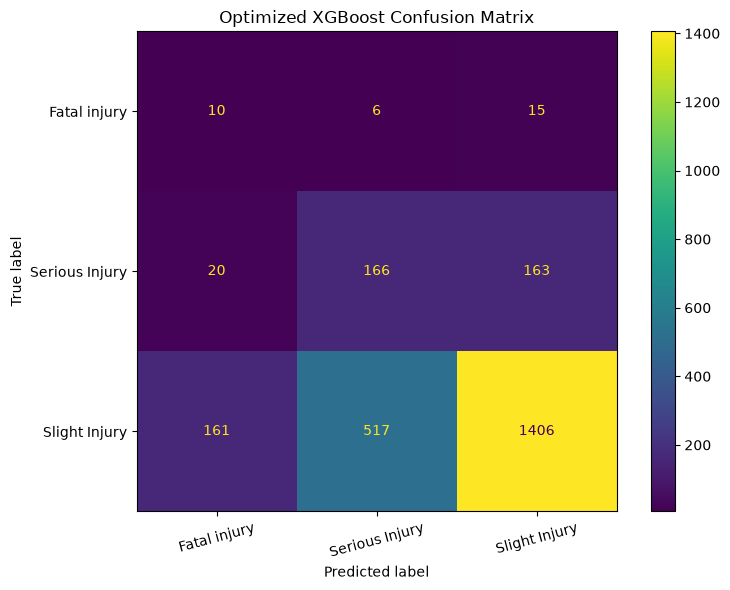

In [107]:
cm_tuned = confusion_matrix(
    y_test,
    y_pred_tuned
)
disp_tuned = ConfusionMatrixDisplay(
    confusion_matrix=cm_tuned,
    display_labels=label_encoder.classes_
)
fig, ax = plt.subplots(figsize=(8, 6))
disp_tuned.plot(
    ax=ax,
    values_format="d"
)
plt.title("Optimized XGBoost Confusion Matrix")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 85. Baseline vs Optimized XGBoost

The baseline and optimized XGBoost models are compared to determine whether hyperparameter tuning resulted in meaningful improvement in balanced classification performance.

In [108]:
xgb_comparison = pd.DataFrame({
    "Model": [
        "Baseline XGBoost",
        "Optimized XGBoost"
    ],
    "Accuracy": [
        accuracy_xgb,
        accuracy_tuned
    ],
    "Macro Precision": [
        precision_xgb,
        precision_tuned
    ],
    "Macro Recall": [
        recall_xgb,
        recall_tuned
    ],
    "Macro F1": [
        f1_xgb,
        f1_tuned
    ]
})
xgb_comparison.round(4)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Baseline XGBoost,0.7378,0.4225,0.4426,0.4297
1,Optimized XGBoost,0.6420,0.3936,0.4910,0.3922


## 86. Complete Model Comparison

All developed models are compared using accuracy, macro precision, macro recall, and macro F1-score.

The comparison includes the class-weighted Random Forest, SMOTE-based Random Forest, baseline weighted XGBoost, and optimized XGBoost.

Macro F1-score is used as the primary selection criterion because it provides balanced evaluation across the highly imbalanced accident severity classes.

In [109]:
complete_model_comparison = pd.DataFrame({
    "Model": [
        "Class-Weighted Random Forest",
        "SMOTE + Random Forest",
        "Baseline Weighted XGBoost",
        "Optimized XGBoost"
    ],
    "Accuracy": [
        accuracy,
        accuracy_smote,
        accuracy_xgb,
        accuracy_tuned
    ],
    "Macro Precision": [
        precision_macro,
        precision_smote,
        precision_xgb,
        precision_tuned
    ],
    "Macro Recall": [
        recall_macro,
        recall_smote,
        recall_xgb,
        recall_tuned
    ],
    "Macro F1": [
        f1_macro,
        f1_smote,
        f1_xgb,
        f1_tuned
    ]
})
complete_model_comparison.round(4)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Class-Weighted Random Forest,0.8462,0.4502,0.3462,0.3334
1,SMOTE + Random Forest,0.8462,0.6154,0.3343,0.3075
2,Baseline Weighted XGBoost,0.7378,0.4225,0.4426,0.4297
3,Optimized XGBoost,0.6420,0.3936,0.4910,0.3922


## 87. Primary Model Selection

Based on the comparative evaluation, the baseline weighted XGBoost model is selected as the primary RoadSafe prediction model.

It achieves the highest Macro F1-score among the evaluated approaches, indicating the best overall balance across the three accident severity classes.

The optimized XGBoost model provides higher recall for the Fatal injury class but has a lower Macro F1-score and therefore remains an alternative experimental model rather than the primary model.

In [110]:
final_model = xgb_model
final_predictions = y_pred_xgb
print("Primary RoadSafe model: Weighted XGBoost")
print(f"Accuracy: {accuracy_xgb:.4f}")
print(f"Macro Precision: {precision_xgb:.4f}")
print(f"Macro Recall: {recall_xgb:.4f}")
print(f"Macro F1-score: {f1_xgb:.4f}")

Primary RoadSafe model: Weighted XGBoost
Accuracy: 0.7378
Macro Precision: 0.4225
Macro Recall: 0.4426
Macro F1-score: 0.4297


## 88. Explainable AI Using SHAP

SHAP (SHapley Additive exPlanations) is used to interpret the predictions of the selected XGBoost model.

The explainability analysis aims to identify the features that contribute most strongly to accident severity predictions and provide interpretable evidence for the RoadSafe risk-analysis component.

In [111]:
import shap
print("SHAP imported successfully.")

SHAP imported successfully.


c:\Users\Niranjan\Desktop\VITc\ACADEMICS\ML\Assignments\RoadSafe\backend\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 89. Preparing Data for SHAP Explainability

SHAP analysis is performed on a representative subset of the unseen testing data to interpret the predictions of the selected XGBoost model.

A subset is used to reduce computational requirements while retaining sufficient observations for meaningful global interpretation.

In [112]:
shap_sample_size = min(1000, len(X_test_processed_df))
X_shap = X_test_processed_df.sample(
    n=shap_sample_size,
    random_state=42
)
print("SHAP sample shape:", X_shap.shape)

SHAP sample shape: (1000, 212)


## 90. Creating the SHAP Explainer

A TreeExplainer is used because the selected RoadSafe model is an XGBoost tree-based model.

The explainer estimates the contribution of individual features to the model's predictions for each accident severity class.

In [113]:
explainer = shap.TreeExplainer(
    final_model
)
print("SHAP TreeExplainer created successfully.")

SHAP TreeExplainer created successfully.


## 91. Calculating SHAP Values

SHAP values are calculated for the selected test samples. Since RoadSafe performs multiclass classification, SHAP values are generated separately for each accident severity class.

In [114]:
shap_values = explainer.shap_values(
    X_shap
)
print("SHAP values calculated successfully.")
if isinstance(shap_values, list):
    print("Number of classes:", len(shap_values))
    for i, values in enumerate(shap_values):
        print(f"Class {i} SHAP shape:", values.shape)
else:
    print("SHAP output shape:", shap_values.shape)

SHAP values calculated successfully.
SHAP output shape: (1000, 212, 3)


## 92. Global SHAP Feature Importance

The mean absolute SHAP value is calculated across all accident severity classes to identify the features that have the greatest overall influence on the XGBoost model's predictions.

Higher mean absolute SHAP values indicate greater influence on the model's predictions and do not imply a causal relationship.

In [115]:
shap_importance = np.abs(shap_values).mean(axis=(0, 2))
shap_importance_df = pd.DataFrame({
    "Feature": X_shap.columns,
    "Mean Absolute SHAP": shap_importance
}).sort_values(
    by="Mean Absolute SHAP",
    ascending=False
)
print("Top 20 globally important features:")
display(shap_importance_df.head(20))

Top 20 globally important features:


,Feature,Mean Absolute SHAP
1,num__Number_of_casualties,0.221641
0,num__Number_of_vehicles_involved,0.178791
99,cat__Types_of_Junction_Crossing,0.099058
32,cat__Driving_experience_Below 1yr,0.074676
123,cat__Weather_conditions_Normal,0.072134
13,cat__Age_band_of_driver_Unknown,0.070386
160,cat__Age_band_of_casualty_18-30,0.054385
67,cat__Defect_of_vehicle_No defect,0.051033
211,cat__Time_period_Night,0.044694
86,cat__Lanes_or_Medians_Undivided Two way,0.044171


## 93. Global SHAP Risk Factor Visualization

The most influential features identified using SHAP are visualized to provide an interpretable ranking of the factors used by the XGBoost model when predicting accident severity.

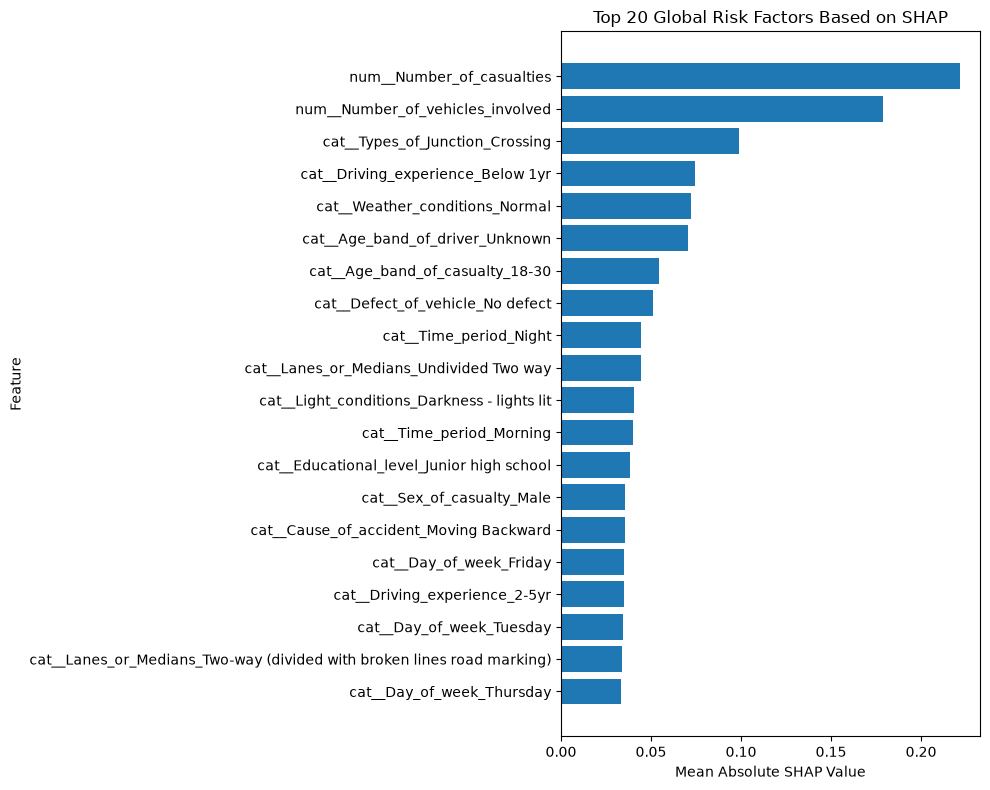

In [116]:
top_shap = shap_importance_df.head(20).sort_values(
    by="Mean Absolute SHAP"
)
plt.figure(figsize=(10, 8))
plt.barh(
    top_shap["Feature"],
    top_shap["Mean Absolute SHAP"]
)
plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.title("Top 20 Global Risk Factors Based on SHAP")
plt.tight_layout()
plt.show()

## 94. SHAP Analysis for Fatal Injury

SHAP contributions are examined specifically for the Fatal injury class to identify the features that most strongly influence predictions toward the most severe accident category.

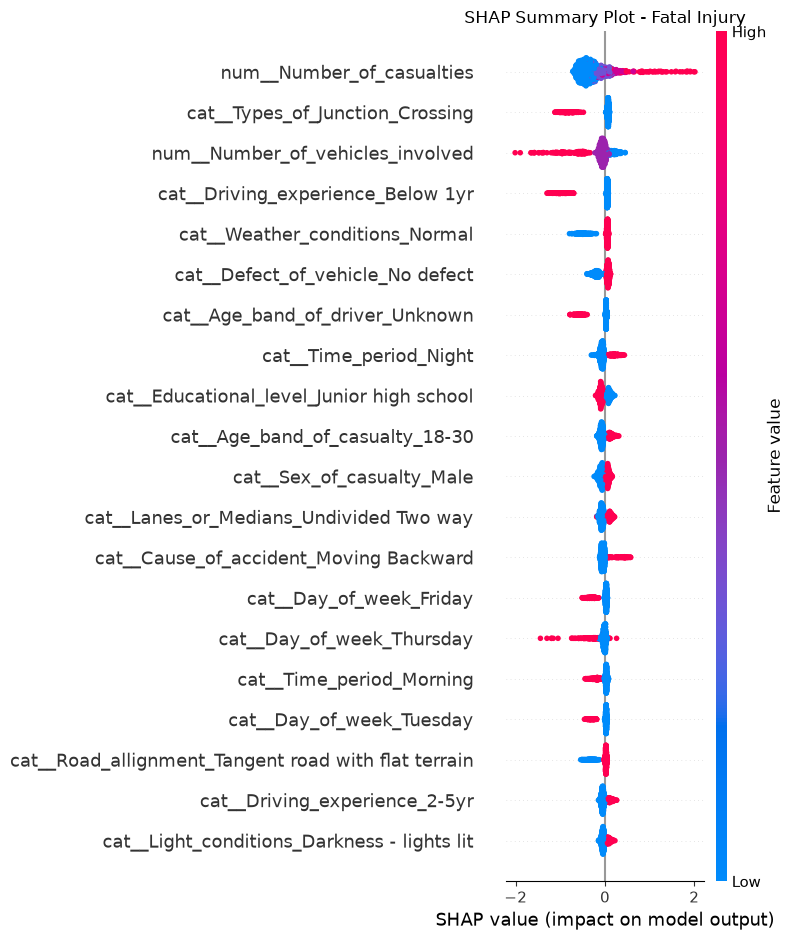

In [117]:
fatal_class_index = 0
shap.summary_plot(
    shap_values[:, :, fatal_class_index],
    X_shap,
    max_display=20,
    show=False
)
plt.title("SHAP Summary Plot - Fatal Injury")
plt.tight_layout()
plt.show()

## 95. SHAP Analysis for Serious Injury

SHAP contributions are examined specifically for the Serious Injury class to identify the features that most strongly influence predictions toward this severity category.

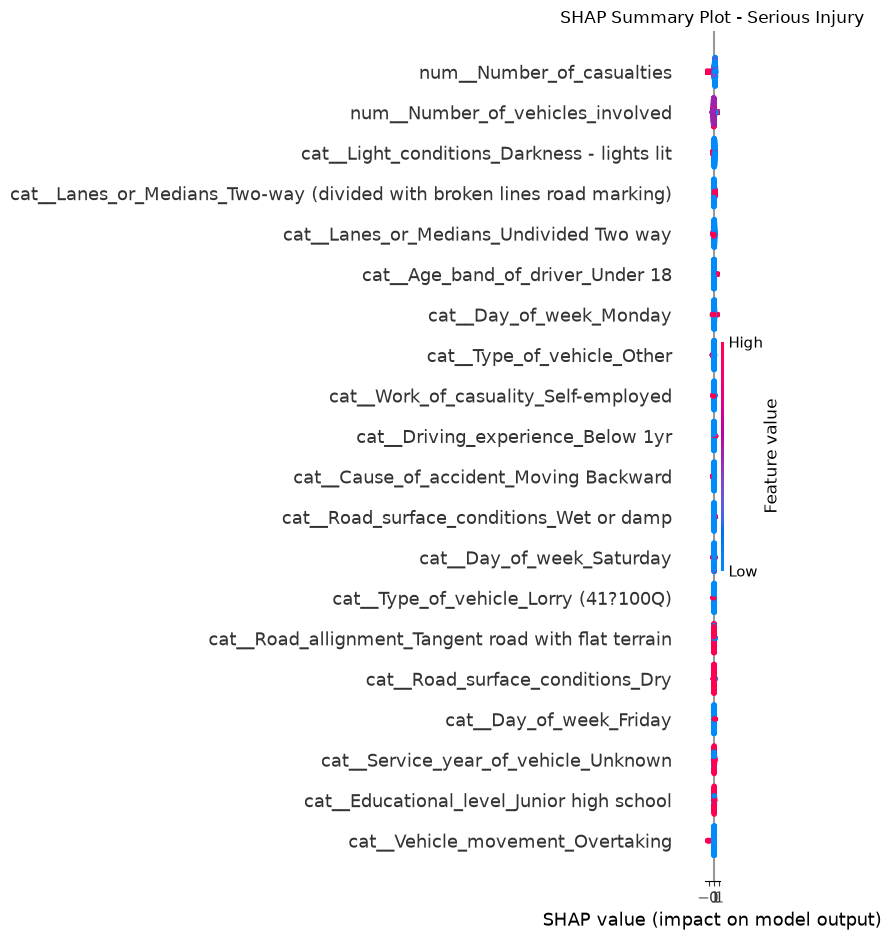

In [118]:
serious_class_index = 1
shap.summary_plot(
    shap_values[:, :, serious_class_index],
    X_shap,
    max_display=20,
    show=False
)
plt.title("SHAP Summary Plot - Serious Injury")
plt.tight_layout()
plt.show()

## 96. SHAP Analysis for Slight Injury

SHAP contributions are examined specifically for the Slight Injury class to identify the features that most strongly influence predictions toward this severity category.

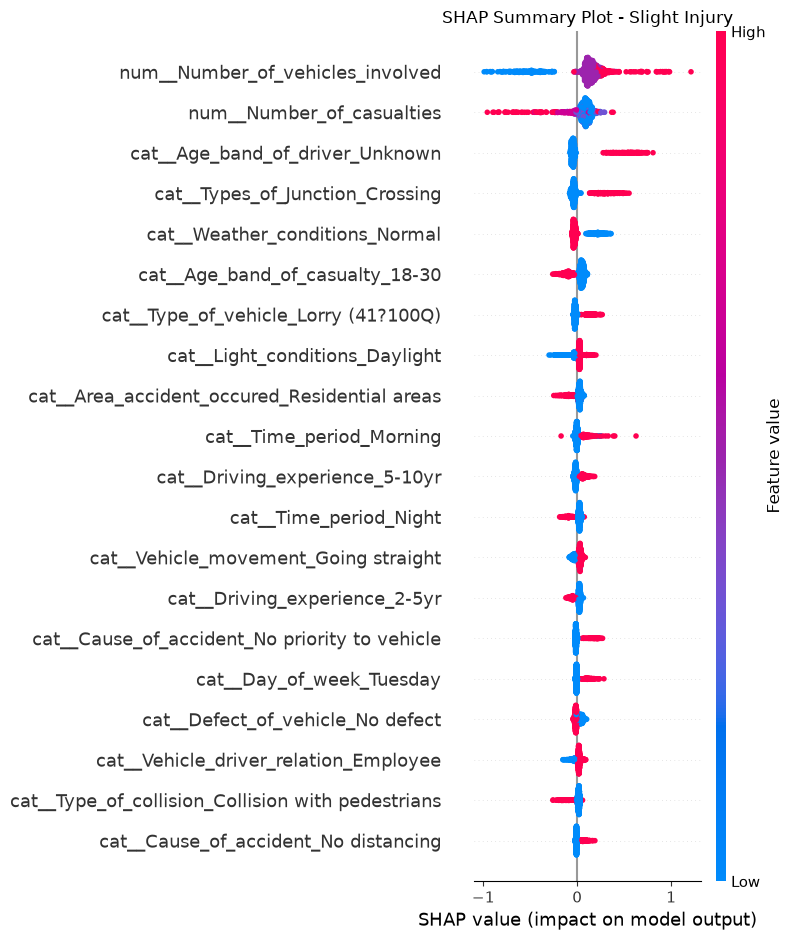

In [119]:
slight_class_index = 2
shap.summary_plot(
    shap_values[:, :, slight_class_index],
    X_shap,
    max_display=20,
    show=False
)
plt.title("SHAP Summary Plot - Slight Injury")
plt.tight_layout()
plt.show()

## 97. Individual Accident Explanation

A single unseen accident from the testing dataset is selected to demonstrate how RoadSafe can provide an interpretable prediction for an individual accident.

The selected accident is explained using both prediction probabilities and SHAP feature contributions.

In [120]:
sample_index = 0
individual_accident = X_shap.iloc[[sample_index]]
print("Selected accident index:", individual_accident.index[0])
print("\nProcessed feature representation:")
display(individual_accident)

Selected accident index: 4028

Processed feature representation:


,num__Number_of_vehicles_involved,num__Number_of_casualties,cat__Day_of_week_Friday,cat__Day_of_week_Monday,cat__Day_of_week_Saturday,cat__Day_of_week_Sunday,cat__Day_of_week_Thursday,cat__Day_of_week_Tuesday,cat__Day_of_week_Wednesday,cat__Age_band_of_driver_18-30,...,cat__Cause_of_accident_Overloading,cat__Cause_of_accident_Overspeed,cat__Cause_of_accident_Overtaking,cat__Cause_of_accident_Overturning,cat__Cause_of_accident_Turnover,cat__Cause_of_accident_Unknown,cat__Time_period_Afternoon,cat__Time_period_Evening,cat__Time_period_Morning,cat__Time_period_Night
4028,1.391737,0.454432,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


## 98. Individual Accident Severity Prediction

The selected accident is passed through the trained XGBoost model to obtain its predicted accident severity and class probabilities.

The probabilities provide an indication of the model's confidence across the three severity categories.

In [121]:
individual_prediction = final_model.predict(
    individual_accident
)[0]
individual_probabilities = final_model.predict_proba(
    individual_accident
)[0]
predicted_severity = label_encoder.inverse_transform(
    [individual_prediction]
)[0]
print("Predicted Accident Severity:", predicted_severity)
print("\nPrediction Probabilities:")
for class_id, probability in enumerate(individual_probabilities):
    class_name = label_encoder.inverse_transform([class_id])[0]
    print(f"{class_name}: {probability:.2%}")

Predicted Accident Severity: Slight Injury

Prediction Probabilities:
Fatal injury: 1.50%
Serious Injury: 39.94%
Slight Injury: 58.57%


## 99. Individual SHAP Explanation

SHAP values are used to identify the features that contributed most strongly to the selected accident's predicted severity.

Positive SHAP values indicate features that pushed the prediction toward the selected class, while negative values indicate features that pushed the prediction away from that class.

In [122]:

predicted_class_index = int(individual_prediction)
individual_shap_values = shap_values[
    sample_index,
    :,
    predicted_class_index
]
individual_explanation = pd.DataFrame({
    "Feature": X_shap.columns,
    "SHAP Value": individual_shap_values
})
individual_explanation["Absolute SHAP"] = (
    individual_explanation["SHAP Value"].abs()
)
individual_explanation = individual_explanation.sort_values(
    by="Absolute SHAP",
    ascending=False
)
print(
    f"Top factors influencing prediction toward "
    f"'{predicted_severity}':"
)
display(
    individual_explanation.head(15)
)

Top factors influencing prediction toward 'Slight Injury':


,Feature,SHAP Value,Absolute SHAP
0,num__Number_of_vehicles_involved,0.282565,0.282565
185,cat__Pedestrian_movement_Unknown or other,-0.130546,0.130546
96,cat__Road_allignment_Tangent road with mountai...,0.117161,0.117161
7,cat__Day_of_week_Tuesday,0.114252,0.114252
160,cat__Age_band_of_casualty_18-30,-0.094436,0.094436
32,cat__Driving_experience_Below 1yr,0.090648,0.090648
99,cat__Types_of_Junction_Crossing,-0.072328,0.072328
142,cat__Vehicle_movement_Going straight,0.066592,0.066592
13,cat__Age_band_of_driver_Unknown,-0.066018,0.066018
208,cat__Time_period_Afternoon,0.045995,0.045995


## 100. Individual Accident Risk Explanation

The most influential SHAP contributions for the selected accident are visualized to provide an interpretable explanation of the model's prediction.

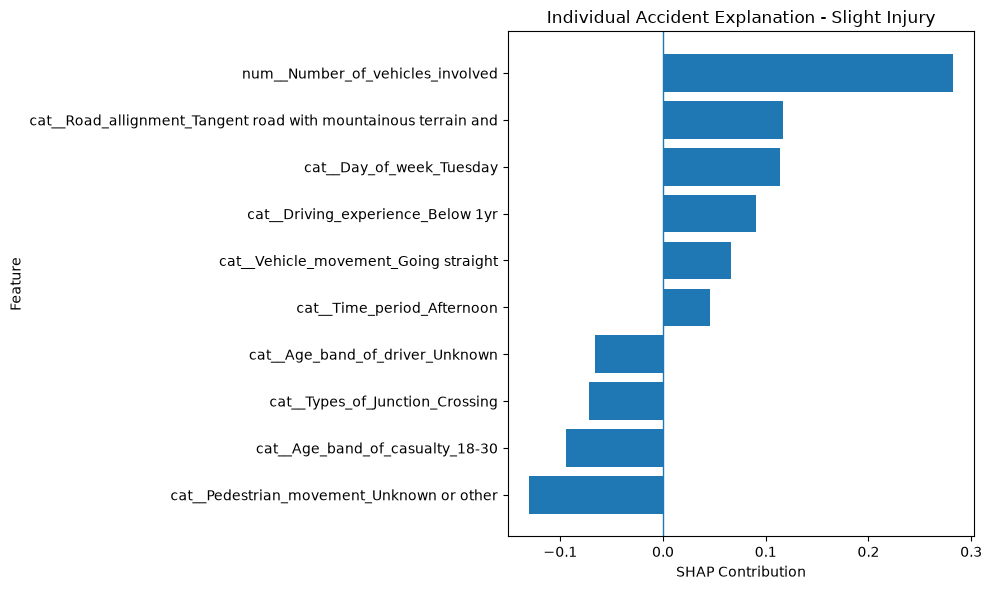

In [123]:
top_individual = individual_explanation.head(10).sort_values(
    by="SHAP Value"
)
plt.figure(figsize=(10, 6))
plt.barh(
    top_individual["Feature"],
    top_individual["SHAP Value"]
)
plt.axvline(
    x=0,
    linewidth=1
)
plt.xlabel("SHAP Contribution")
plt.ylabel("Feature")
plt.title(
    f"Individual Accident Explanation - {predicted_severity}"
)
plt.tight_layout()
plt.show()

## 101. RoadSafe Interpretable Prediction Summary

The model output is converted into a concise human-readable summary containing the predicted accident severity, prediction probabilities, and the strongest factors contributing to the prediction.

In [124]:
print("=" * 55)
print("              ROADSAFE PREDICTION")
print("=" * 55)
print(f"\nPredicted Severity: {predicted_severity}")
print("\nPrediction Confidence:")
for class_id, probability in enumerate(individual_probabilities):
    class_name = label_encoder.inverse_transform([class_id])[0]
    print(f"  {class_name}: {probability:.2%}")
print("\nTop Influencing Factors:")
for _, row in individual_explanation.head(5).iterrows():
    direction = "increased" if row["SHAP Value"] > 0 else "decreased"
    print(
        f"  • {row['Feature']} "
        f"({direction} influence)"
    )
print("=" * 55)

              ROADSAFE PREDICTION

Predicted Severity: Slight Injury

Prediction Confidence:
  Fatal injury: 1.50%
  Serious Injury: 39.94%
  Slight Injury: 58.57%

Top Influencing Factors:
  • num__Number_of_vehicles_involved (increased influence)
  • cat__Pedestrian_movement_Unknown or other (decreased influence)
  • cat__Road_allignment_Tangent road with mountainous terrain and (increased influence)
  • cat__Day_of_week_Tuesday (increased influence)
  • cat__Age_band_of_casualty_18-30 (decreased influence)
